In [1]:
import os
import json
import pandas as pd

# ✅ Day 6: JSON File Handling (Memory Efficient Chunked Processing)

# Create output directory
os.makedirs("data", exist_ok=True)

# Set your JSON file path
json_file_path = "Traffic_congestion.json"

# Load JSON in chunks (line-by-line)
records = []

with open(json_file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i % 100000 == 0:
            print(f"Processing line {i}")
        try:
            record = json.loads(line)
            records.append(record)
        except json.JSONDecodeError:
            continue

# Convert to DataFrame
df_json = pd.DataFrame(records)

# Save to CSV
df_json.to_csv("data/traffic_congestion_day6_output.csv", index=False)
print("✅ Output saved as data/traffic_congestion_day6_output.csv")


Processing line 0
Processing line 100000
Processing line 200000
Processing line 300000
Processing line 400000
Processing line 500000
Processing line 600000
Processing line 700000
Processing line 800000
Processing line 900000
Processing line 1000000
Processing line 1100000
Processing line 1200000
Processing line 1300000
Processing line 1400000
Processing line 1500000
Processing line 1600000
Processing line 1700000
Processing line 1800000
Processing line 1900000
Processing line 2000000
Processing line 2100000
Processing line 2200000
Processing line 2300000
Processing line 2400000
Processing line 2500000
Processing line 2600000
Processing line 2700000
Processing line 2800000
Processing line 2900000
Processing line 3000000
Processing line 3100000
Processing line 3200000
Processing line 3300000
Processing line 3400000
Processing line 3500000
Processing line 3600000
Processing line 3700000
Processing line 3800000
Processing line 3900000
Processing line 4000000
Processing line 4100000
Process

In [1]:
from rdflib import Graph
import pandas as pd
import os
# Day 8: RDF File Handling (Memory Efficient Chunked Processing)

# Create output directory
os.makedirs("data", exist_ok=True)

# Load RDF file
g = Graph()
g.parse("rows.rdf", format="xml")

# Convert the RDF triples into list of dictionaries
triples = []
for subj, pred, obj in g:
    triples.append({
        'subject': str(subj),
        'predicate': str(pred),
        'object': str(obj)
    })

# Convert to DataFrame
df_rdf = pd.DataFrame(triples)

# Save to CSV
df_rdf.to_csv("data/traffic_congestion_day8_output.csv", index=False)
print("✅ Output saved as data/traffic_congestion_day8_output.csv")





✅ Output saved as data/traffic_congestion_day8_output.csv


Sample Data:
                     TIME  REGION_ID  SPEED                          REGION  \
0  03/31/2018 02:40:28 PM          2  27.95                  Far North West   
1  03/31/2018 02:40:28 PM          3  19.09    North Park-Albany-Linconl Sq   
2  03/31/2018 02:40:28 PM          4  18.41               Edge Water-Uptown   
3  03/31/2018 02:40:28 PM          6  20.45  Irving Park-Avondale-North Ctr   
4  03/31/2018 02:40:28 PM          7  18.41            Hermosa-Logan Square   

   BUS_COUNT  NUM_READS  HOUR  DAY_OF_WEEK  MONTH  \
0         25        493    14            7      3   
1         48        834    14            7      3   
2         36        585    14            7      3   
3         48        811    14            7      3   
4         47        817    14            7      3   

                                   DESCRIPTION        RECORD_ID       WEST  \
0      North of Montrose. East River to Cicero  02-201803311940 -87.846210   
1      Montrose to Devon. Cicero to R

C:\Users\HP\AppData\Local\Temp\ipykernel_8220\1079691358.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TIME'] = pd.to_datetime(df['TIME'], errors='coerce')


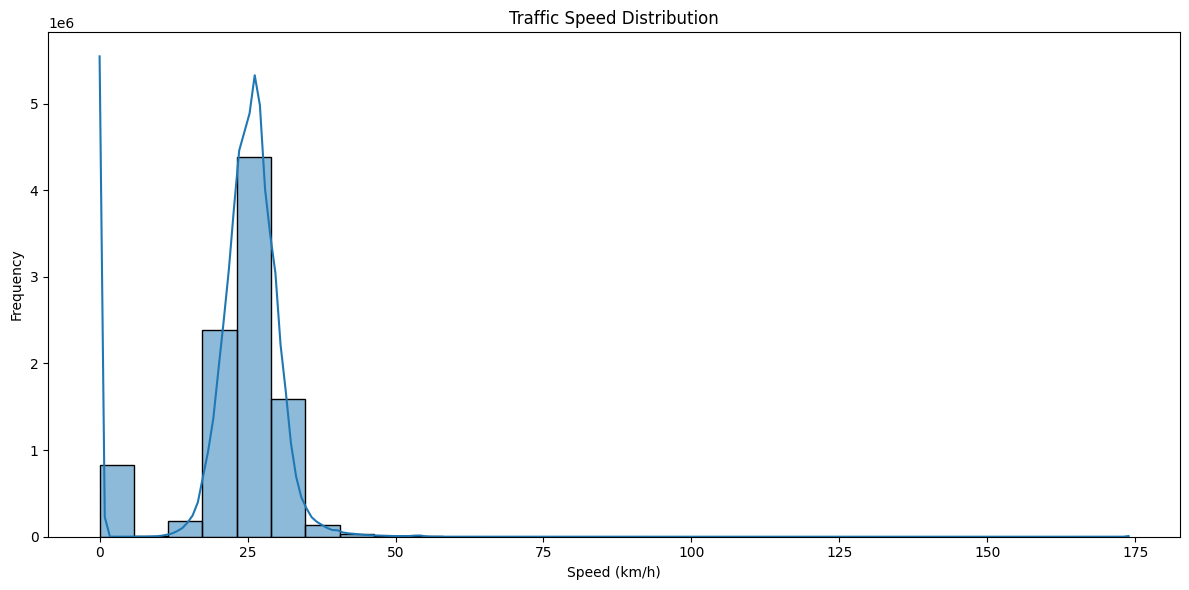

C:\Users\HP\AppData\Local\Temp\ipykernel_8220\1079691358.py:49: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='HOUR', y='SPEED', ci=None, estimator='mean', order=sorted(df['HOUR'].unique()))


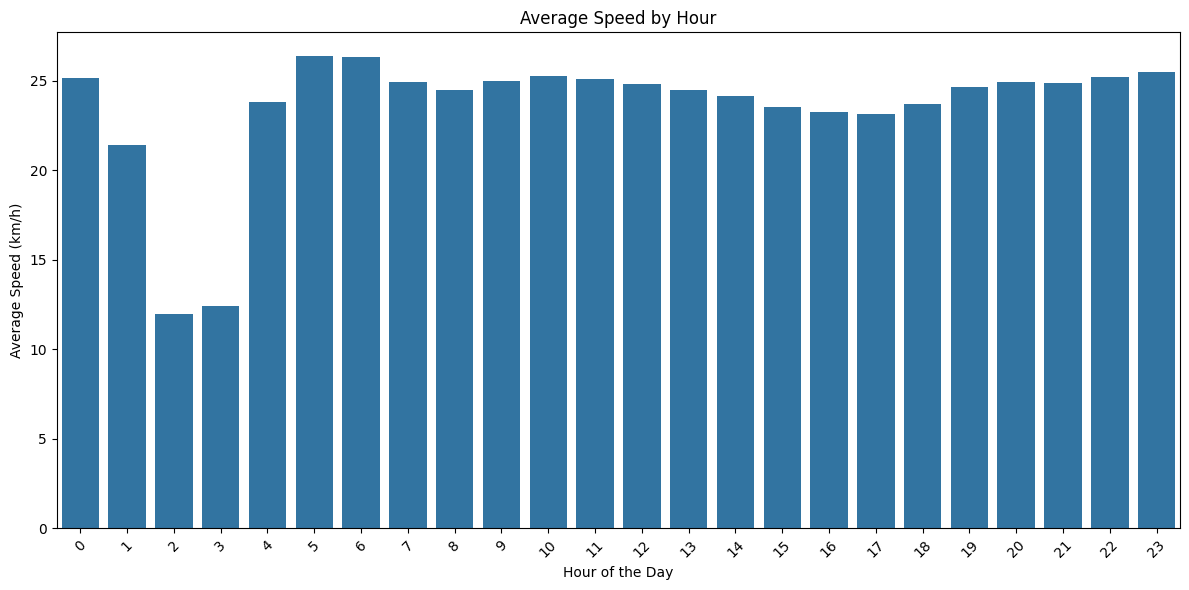

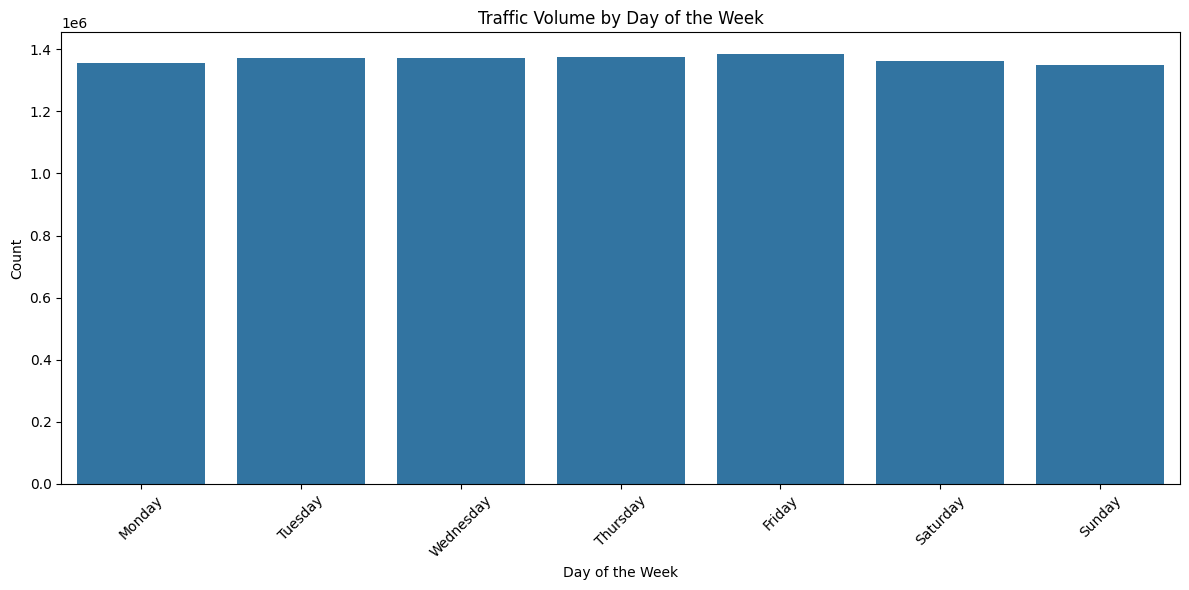

 Cleaned data saved as data/cleaned_traffic_congestion.csv
Cleaned Data Sample:


In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Load the csv file
df = pd.read_csv("Historical_Traffic_Congestion.csv")

# Display the first five rows of the DataFrame
print("Sample Data:")
print(df.head())

# Data shape 
print("\nData Shape:")

# Summary statistics
print(df.describe(include="all"))
print("\nData Shape:", df.shape)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Unique regions
print("\nUnique Regions:")
print(df['REGION'].value_counts())

# Convert the time coloumn to datetime format
df['TIME'] = pd.to_datetime(df['TIME'], errors='coerce')

# Extract hour from the time column
df['HOUR'] = df['TIME'].dt.hour
df['DAY'] = df['TIME'].dt.day_name()

# Plotting the traffic congestion by speed
plt.figure(figsize=(12,6))
sns.histplot(df['SPEED'].dropna(), bins=30, kde=True)
plt.title('Traffic Speed Distribution')
plt.xlabel('Speed (km/h)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("data/traffic_speed_distribution.png")
plt.show()



# Average speed by hour 
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='HOUR', y='SPEED', ci=None, estimator='mean', order=sorted(df['HOUR'].unique()))
plt.title('Average Speed by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Speed (km/h)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/average_speed_by_hour.png")
plt.show()

# Plotting traffic volume by day of the week
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='DAY', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Traffic Volume by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/traffic_volume_by_day.png")
plt.show()

# Save the cleaned DataFrame to a new CSV file
df.to_csv("data/cleaned_traffic_congestion.csv", index=False)
print(" Cleaned data saved as data/cleaned_traffic_congestion.csv")
# Load the cleaned DataFrame
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
# Display the first five rows of the cleaned DataFrame
print("Cleaned Data Sample:")



In [2]:
import pandas as pd

# Load the cleaned DataFrame
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
print(df_cleaned.head())
print(" Data Loaded Successfully")

                  TIME  REGION_ID  SPEED                          REGION  \
0  2018-03-31 14:40:28          2  27.95                  Far North West   
1  2018-03-31 14:40:28          3  19.09    North Park-Albany-Linconl Sq   
2  2018-03-31 14:40:28          4  18.41               Edge Water-Uptown   
3  2018-03-31 14:40:28          6  20.45  Irving Park-Avondale-North Ctr   
4  2018-03-31 14:40:28          7  18.41            Hermosa-Logan Square   

   BUS_COUNT  NUM_READS  HOUR  DAY_OF_WEEK  MONTH  \
0         25        493    14            7      3   
1         48        834    14            7      3   
2         36        585    14            7      3   
3         48        811    14            7      3   
4         47        817    14            7      3   

                                   DESCRIPTION        RECORD_ID       WEST  \
0      North of Montrose. East River to Cicero  02-201803311940 -87.846210   
1      Montrose to Devon. Cicero to Ravenswood  03-201803311940 -87.

In [10]:
import pandas as pd

# Step 1: Load the cleaned CSV file (change filename if needed)
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
# Step 2: Convert SPEED and REGION_ID to numeric and TIME to datetime
df_cleaned['TIME'] = pd.to_datetime(df_cleaned['TIME'], errors='coerce')
df_cleaned['SPEED'] = pd.to_numeric(df_cleaned['SPEED'], errors='coerce')
df_cleaned['REGION_ID'] = pd.to_numeric(df_cleaned['REGION_ID'], errors='coerce')

# Step 3: Display data types
print("Column Data Types:\n")
print(df_cleaned.dtypes)

# Step 4: Check for missing values
print("\n Missing Values:\n")
print(df_cleaned.isnull().sum())

# Optional: Quick look at data
print("\n First 5 Rows:\n")
print(df_cleaned.head())


Column Data Types:

TIME           datetime64[ns]
REGION_ID               int64
SPEED                 float64
REGION                 object
BUS_COUNT               int64
NUM_READS               int64
HOUR                    int64
DAY_OF_WEEK             int64
MONTH                   int64
DESCRIPTION            object
RECORD_ID              object
WEST                  float64
EAST                  float64
SOUTH                 float64
NORTH                 float64
NW_LOCATION            object
SE_LOCATION            object
DAY                    object
dtype: object

 Missing Values:

TIME           0
REGION_ID      0
SPEED          0
REGION         0
BUS_COUNT      0
NUM_READS      0
HOUR           0
DAY_OF_WEEK    0
MONTH          0
DESCRIPTION    0
RECORD_ID      0
WEST           0
EAST           0
SOUTH          0
NORTH          0
NW_LOCATION    0
SE_LOCATION    0
DAY            0
dtype: int64

 First 5 Rows:

                 TIME  REGION_ID  SPEED                          REGION

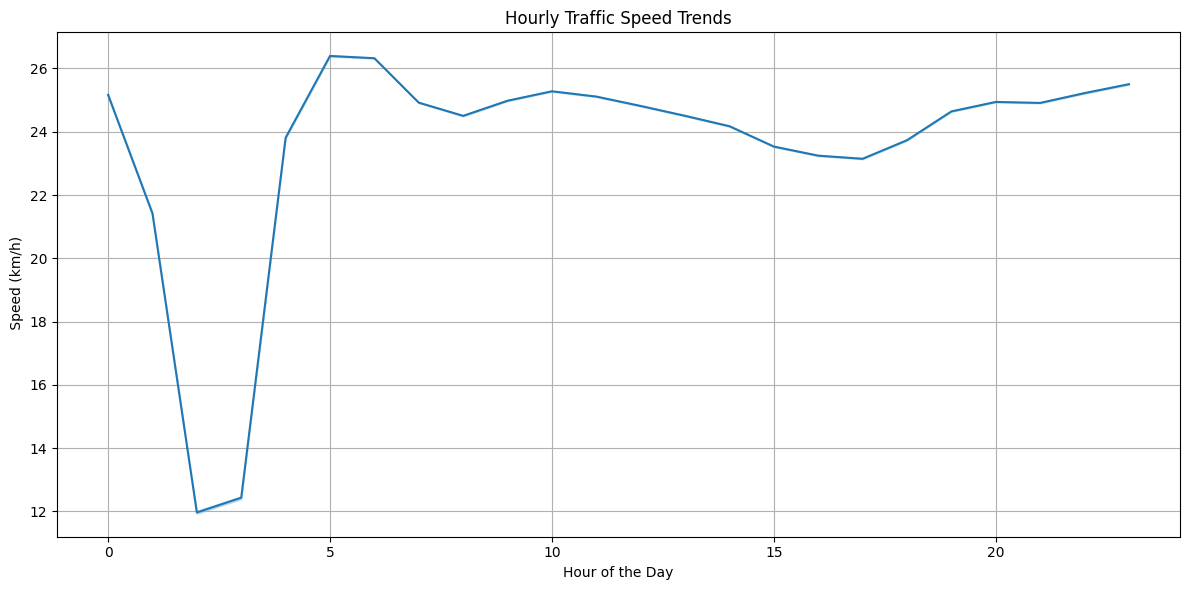

In [11]:
# Plot Hourly Traffic Speed trends
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new column for hour
df_cleaned['HOUR'] = df_cleaned['TIME'].dt.hour

plt.figure(figsize=(12,6))
sns.lineplot(data=df_cleaned, x='HOUR', y='SPEED')
plt.title('Hourly Traffic Speed Trends')
plt.xlabel('Hour of the Day')
plt.ylabel(' Speed (km/h)')
plt.grid(True)
plt.tight_layout()
plt.savefig("data/hourly_traffic_speed_trends.png")
plt.show()

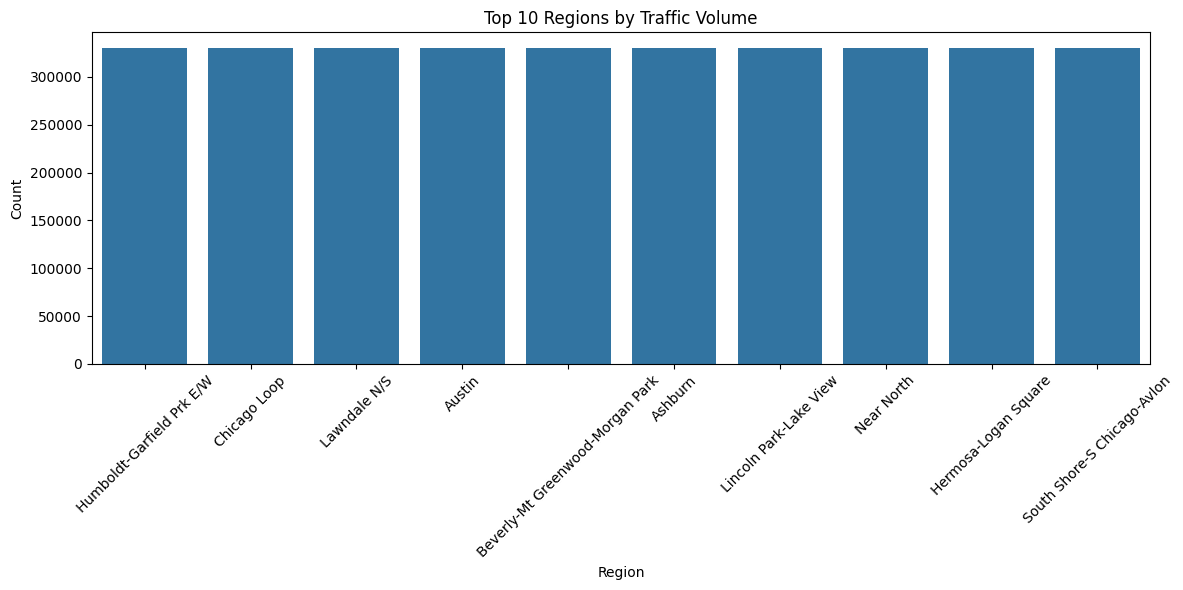

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting top regions 

top_regions = df_cleaned['REGION'].value_counts().nlargest(10).index
plt.figure(figsize=(12,6))
sns.countplot(data=df_cleaned[df_cleaned['REGION'].isin(top_regions)], x='REGION', order=top_regions)
plt.title('Top 10 Regions by Traffic Volume')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/top_regions_traffic_volume.png")
plt.show()

In [14]:

import pandas as pd 

# Step 1 Load the cleaned csv
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
print(" Loaded Data :")

# Step 2 Encode categorical feature 'REGION' to numeric
df_cleaned['REGION_ENCODED'] = df_cleaned['REGION'].astype('category').cat.codes

# Step 3 Encode 'DAY_OF_WEEK'
df_cleaned['DAY_OF_WEEK_ENCODED'] = df_cleaned['DAY_OF_WEEK'].astype('category').cat.codes

# Step 4 Convert Time to datetime and extract new features 
df_cleaned['TIME'] = pd.to_datetime(df_cleaned['TIME'], errors = 'coerce')
df_cleaned['HOUR'] = df_cleaned['TIME'].dt.hour
df_cleaned['MINUTE'] = df_cleaned['TIME'].dt.minute

# step 5 Create directional flow total (sum of all directions)
directional_cols= ['NORTH','SOUTH','EAST','WEST']
df_cleaned['TOTAL_FLOW'] = df_cleaned[directional_cols].sum(axis=1)

# Check correlation matrix 
correlation = df_cleaned[['SPEED','BUS_COUNT','NUM_READS','REGION_ENCODED','TOTAL_FLOW']].corr
print("Correlation Matrix:", correlation)

# Step 6 Save the feature engineered data
df_cleaned.to_csv("data/engineered_traffic_dataset.csv",index = False)
print("Feature engineered dataset saved as 'engineered_traffic_dataset.csv' ")

 Loaded Data :
Correlation Matrix: <bound method DataFrame.corr of          SPEED  BUS_COUNT  NUM_READS  REGION_ENCODED  TOTAL_FLOW
0        27.95         25        493               9  -91.613897
1        19.09         48        834              21  -91.463431
2        18.41         36        585               8  -91.362413
3        20.45         48        811              14  -91.529536
4        18.41         47        817              11  -91.580936
...        ...        ...        ...             ...         ...
9572245  30.68          9        142              25  -91.640184
9572246  31.50          6        137               2  -91.748005
9572247  28.64         13        183              10  -91.655798
9572248  25.91         13        239               7  -91.723728
9572249  30.27         10        117              19  -91.545353

[9572250 rows x 5 columns]>
Feature engineered dataset saved as 'engineered_traffic_dataset.csv' 


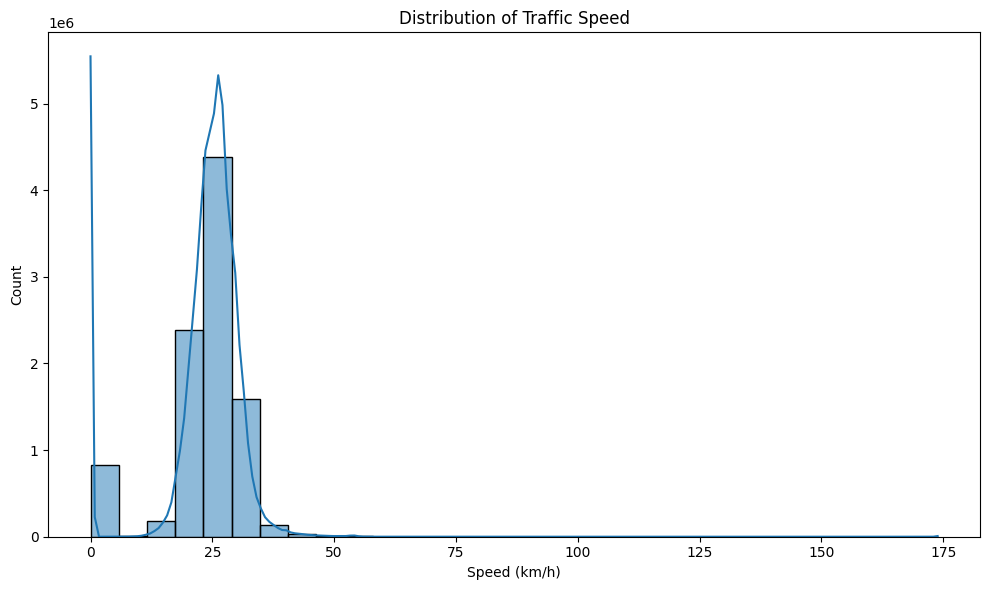

C:\Users\HP\AppData\Local\Temp\ipykernel_19300\3276873223.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_regions, y=df_engineered['REGION'].value_counts().nlargest(5), palette='viridis')


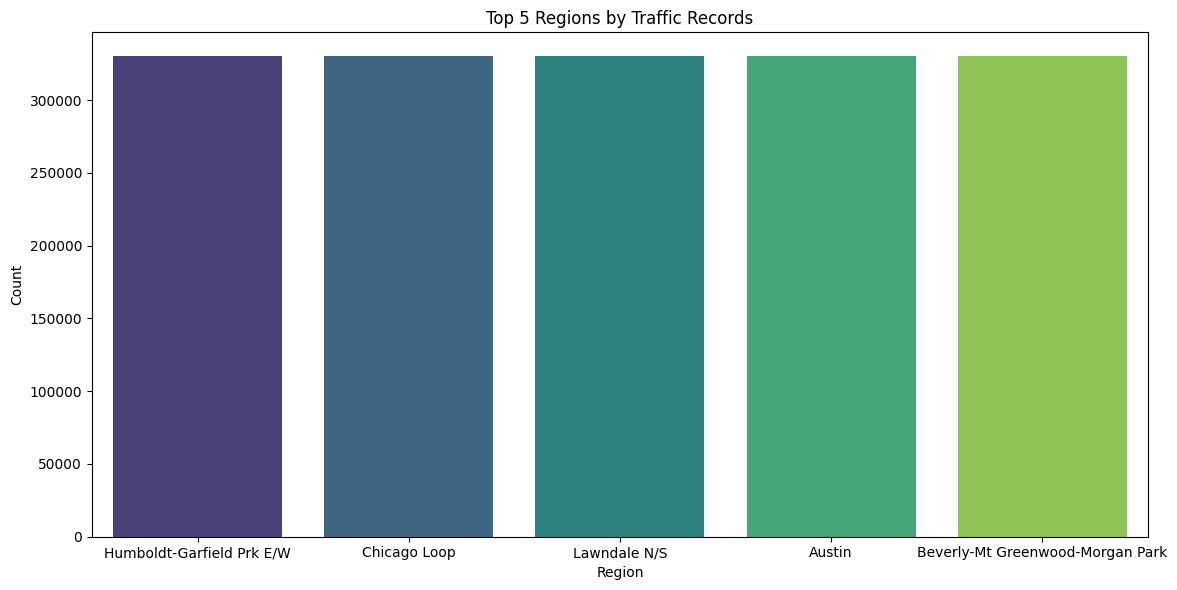

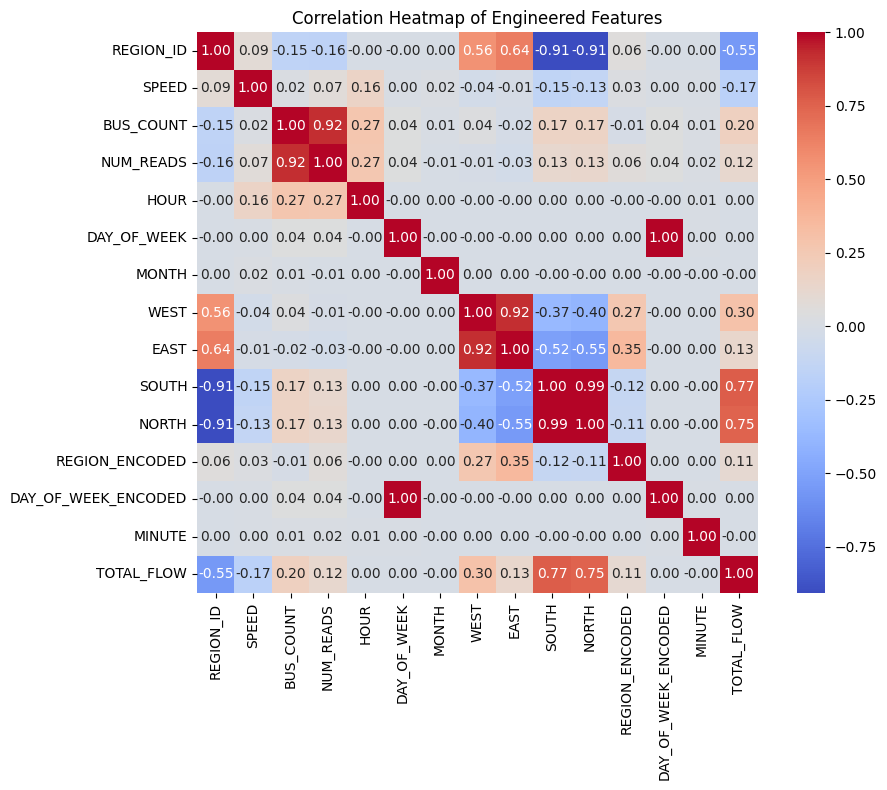

C:\Users\HP\AppData\Local\Temp\ipykernel_19300\3276873223.py:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_engineered, x='HOUR', y='SPEED', ci=None, estimator='mean', order=sorted(df_engineered['HOUR'].unique()))


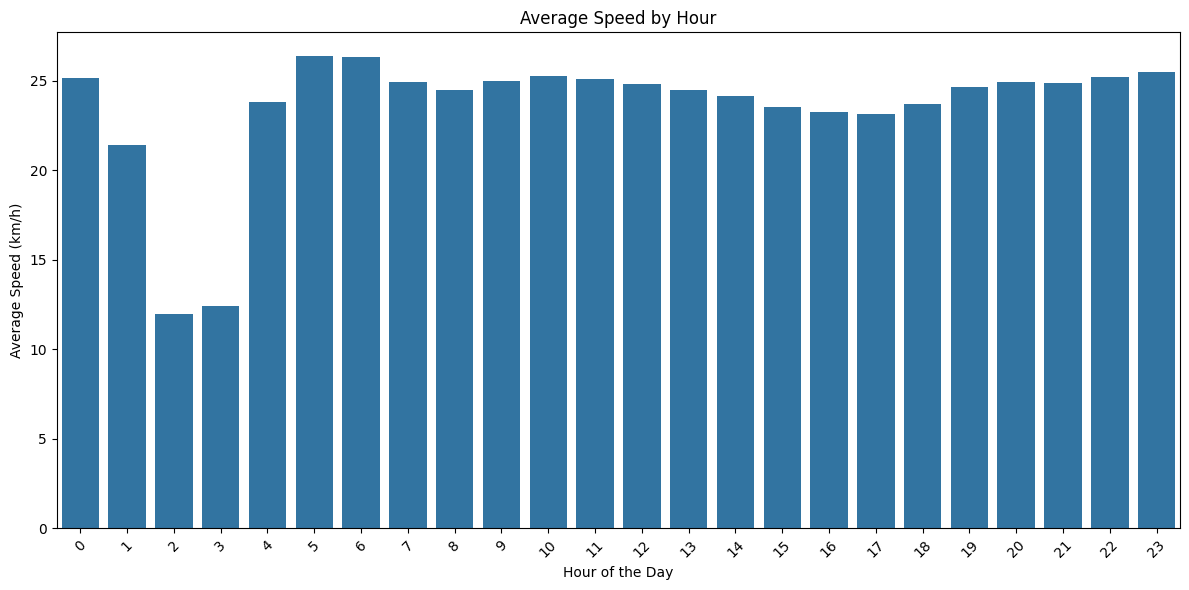

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the feature engineered dataset
df_engineered = pd.read_csv("data/engineered_traffic_dataset.csv")

# Display histogram of SPEED
plt.figure(figsize=(10, 6))
sns.histplot(df_engineered['SPEED'].dropna(), bins=30, kde=True)
plt.title('Distribution of Traffic Speed')
plt.xlabel('Speed (km/h)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("data/traffic_speed_distribution.png")
plt.show()

# Top 5 regions with highest traffic records 
top_regions = df_engineered['REGION'].value_counts().nlargest(5).index
plt.figure(figsize=(12, 6))
sns.barplot(x=top_regions, y=df_engineered['REGION'].value_counts().nlargest(5), palette='viridis')
plt.title('Top 5 Regions by Traffic Records')
plt.xlabel('Region')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("data/top_regions_traffic_records.png")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_df = df_engineered.select_dtypes(include='number')  # Only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Engineered Features')
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png")
plt.show()

# Average speed by hour
if 'HOUR' in df_engineered.columns:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_engineered, x='HOUR', y='SPEED', ci=None, estimator='mean', order=sorted(df_engineered['HOUR'].unique()))
    plt.title('Average Speed by Hour')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Average Speed (km/h)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("data/average_speed_by_hour.png")
    plt.show()

In [17]:
import pandas as pd
# load the cleaned DataFrame
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
print(df_cleaned.head())
print(" Data Loaded Successfully")

                  TIME  REGION_ID  SPEED                          REGION  \
0  2018-03-31 14:40:28          2  27.95                  Far North West   
1  2018-03-31 14:40:28          3  19.09    North Park-Albany-Linconl Sq   
2  2018-03-31 14:40:28          4  18.41               Edge Water-Uptown   
3  2018-03-31 14:40:28          6  20.45  Irving Park-Avondale-North Ctr   
4  2018-03-31 14:40:28          7  18.41            Hermosa-Logan Square   

   BUS_COUNT  NUM_READS  HOUR  DAY_OF_WEEK  MONTH  \
0         25        493    14            7      3   
1         48        834    14            7      3   
2         36        585    14            7      3   
3         48        811    14            7      3   
4         47        817    14            7      3   

                                   DESCRIPTION        RECORD_ID       WEST  \
0      North of Montrose. East River to Cicero  02-201803311940 -87.846210   
1      Montrose to Devon. Cicero to Ravenswood  03-201803311940 -87.

In [18]:
import pandas as pd
# Load the feature engineered dataset
df_cleaned= pd.read_csv("data/cleaned_traffic_congestion.csv")
print(df_cleaned.head())
print(" Data Loaded Successfully")

# Encode REGION as numeric
df_cleaned['REGION_ENCODED'] = df_cleaned['REGION'].astype('category').cat.codes
print("REGION_ENCODED added successfully")

# Convert TIME to datetime and extract hour
df_cleaned['TIME'] = pd.to_datetime(df_cleaned['TIME'],errors ='coerce')
df_cleaned['HOUR'] = df_cleaned['TIME'].dt.hour
df_cleaned['DAY_OF_WEEK'] = df_cleaned['TIME'].dt.day_name()
df_cleaned['MONTH'] = df_cleaned['TIME'].dt.month

# Only keep numeric columns 
df_cleaned_numeric = df_cleaned.select_dtypes(include=['number'])

                  TIME  REGION_ID  SPEED                          REGION  \
0  2018-03-31 14:40:28          2  27.95                  Far North West   
1  2018-03-31 14:40:28          3  19.09    North Park-Albany-Linconl Sq   
2  2018-03-31 14:40:28          4  18.41               Edge Water-Uptown   
3  2018-03-31 14:40:28          6  20.45  Irving Park-Avondale-North Ctr   
4  2018-03-31 14:40:28          7  18.41            Hermosa-Logan Square   

   BUS_COUNT  NUM_READS  HOUR  DAY_OF_WEEK  MONTH  \
0         25        493    14            7      3   
1         48        834    14            7      3   
2         36        585    14            7      3   
3         48        811    14            7      3   
4         47        817    14            7      3   

                                   DESCRIPTION        RECORD_ID       WEST  \
0      North of Montrose. East River to Cicero  02-201803311940 -87.846210   
1      Montrose to Devon. Cicero to Ravenswood  03-201803311940 -87.

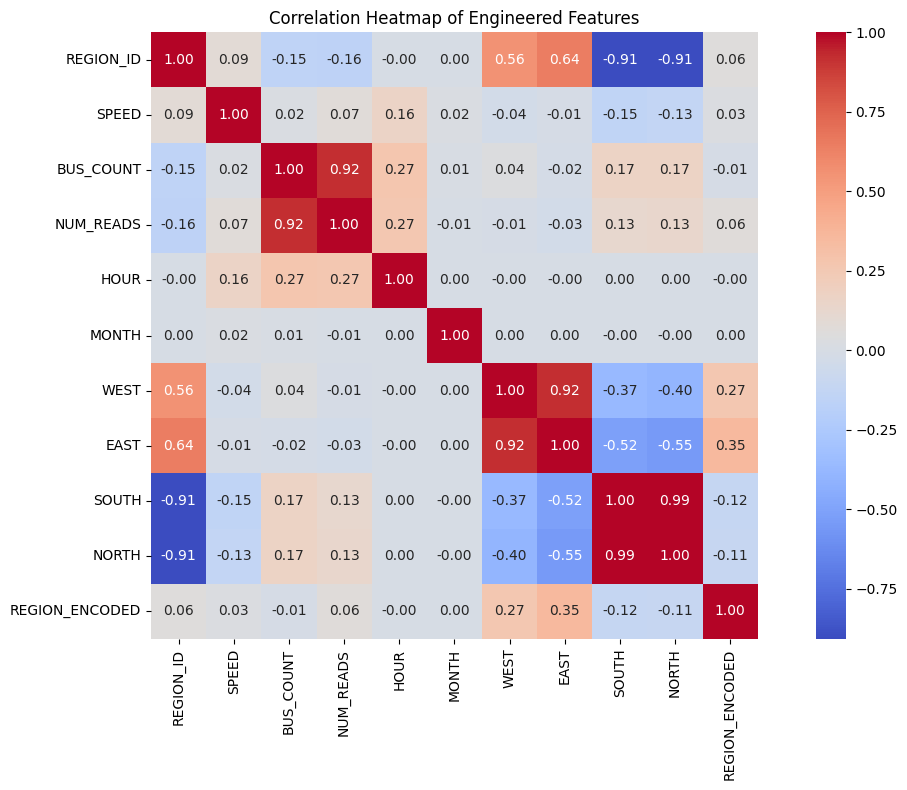

In [19]:
# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.heatmap(df_cleaned_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Engineered Features')
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png")
plt.show()

In [2]:
# Load the feature engineered dataset
df_engineered = pd.read_csv("data/engineered_traffic_dataset.csv")
print(df_engineered.head())
print(" Data Loaded Successfully")

                  TIME  REGION_ID  SPEED                          REGION  \
0  2018-03-31 14:40:28          2  27.95                  Far North West   
1  2018-03-31 14:40:28          3  19.09    North Park-Albany-Linconl Sq   
2  2018-03-31 14:40:28          4  18.41               Edge Water-Uptown   
3  2018-03-31 14:40:28          6  20.45  Irving Park-Avondale-North Ctr   
4  2018-03-31 14:40:28          7  18.41            Hermosa-Logan Square   

   BUS_COUNT  NUM_READS  HOUR  DAY_OF_WEEK  MONTH  \
0         25        493    14            7      3   
1         48        834    14            7      3   
2         36        585    14            7      3   
3         48        811    14            7      3   
4         47        817    14            7      3   

                                   DESCRIPTION  ...       EAST      SOUTH  \
0      North of Montrose. East River to Cicero  ... -87.747456  41.960669   
1      Montrose to Devon. Cicero to Ravenswood  ... -87.674590  41.960

C:\Users\HP\AppData\Local\Temp\ipykernel_13496\1030553765.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_engineered, x='HOUR', y='SPEED' , ci=None, estimator='mean')


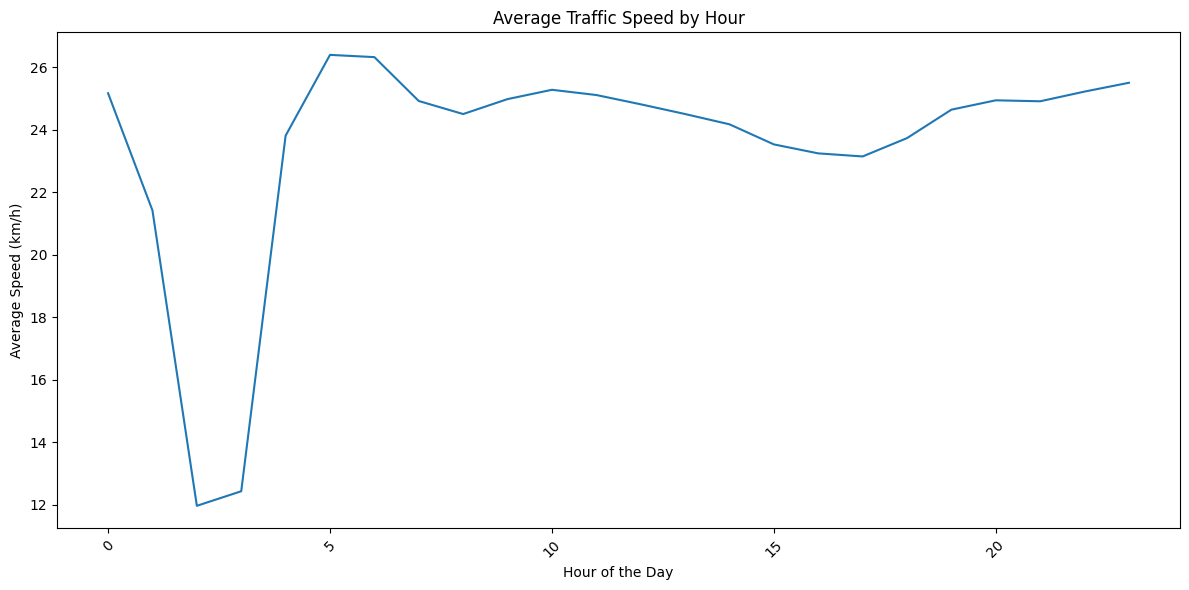

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert TIME to datetime if not already done
df_engineered['TIME'] = pd.to_datetime(df_engineered['TIME'],errors = 'coerce')
df_engineered['HOUR'] = df_engineered['TIME'].dt.hour
df_engineered['DAY_OF_WEEK'] = df_engineered['TIME'].dt.day_name()  

# Plot average speed by hour
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_engineered, x='HOUR', y='SPEED' , ci=None, estimator='mean')
plt.title('Average Traffic Speed by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Speed (km/h)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/average_speed_by_hour.png")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_13496\3952391243.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_regions, x='REGION', y='SPEED', palette='viridis')


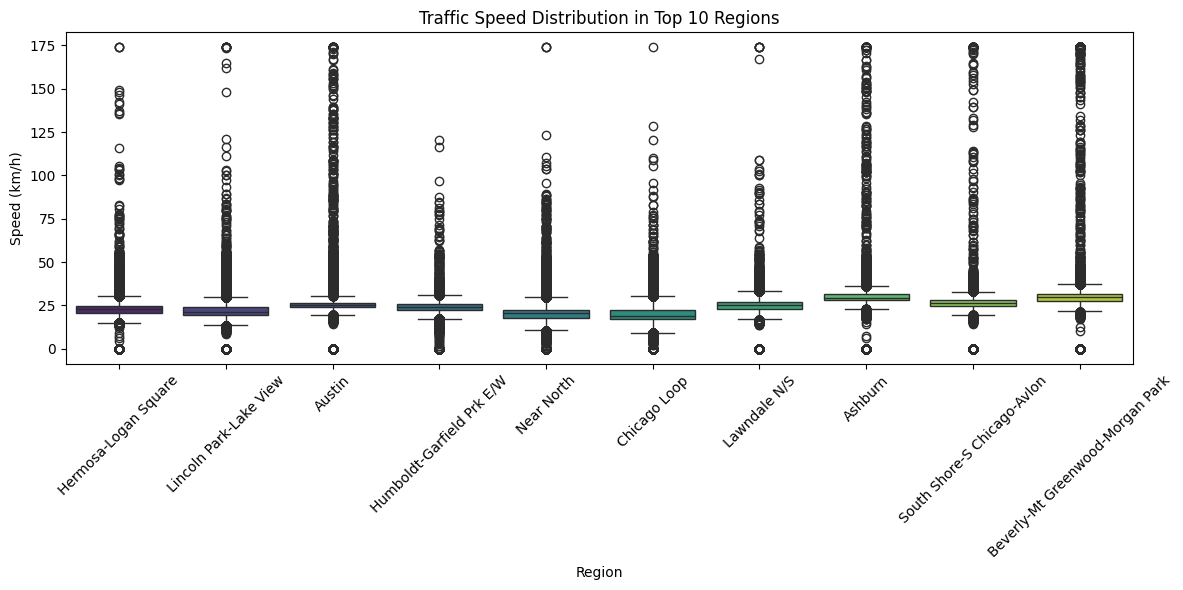

                 Region  Mean_Speed  Speed_STD  Record_Count
22  Riverdale-Hegewisch   18.784809  18.257423        330076
6    Downtown Lakefront   18.911656   9.550645        330078
5          Chicago Loop   19.318372   4.787602        330080
18           Near North   19.395185   6.681757        330079
8     Edge Water-Uptown   20.102693   7.240010        330078
✅ Region-level speed summary exported.


In [6]:
# Spatial Analysis 
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 most effective regions
top_regions = df_engineered['REGION'].value_counts().nlargest(10).index

# Filter the DataFrame for these regions
df_top_regions = df_engineered[df_engineered['REGION'].isin(top_regions)]
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_regions, x='REGION', y='SPEED', palette='viridis')
plt.title('Traffic Speed Distribution in Top 10 Regions')
plt.xlabel('Region')
plt.ylabel('Speed (km/h)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/traffic_speed_top_regions.png")
plt.show()

# Mean and variance of speed by region
region_stats = df_engineered.groupby('REGION')['SPEED'].agg(['mean', 'std', 'count']).reset_index()
region_stats.columns = ['Region', 'Mean_Speed', 'Speed_STD', 'Record_Count']
print(region_stats.sort_values(by='Mean_Speed').head(5))

region_stats.to_csv("data/region_speed_summary.csv", index=False)
print("✅ Region-level speed summary exported.")




In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load cleaned dataset
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
print("✅ Data Loaded Successfully")

# Select features and target variable
features = df_cleaned[['REGION', 'HOUR', 'DAY_OF_WEEK', 'MONTH', 'REGION_ID', 'BUS_COUNT', 'NUM_READS']]
target = df_cleaned['SPEED']

# Encode 'REGION' if it's categorical
le = LabelEncoder()
features['REGION'] = le.fit_transform(features['REGION'])

# Drop missing values
features = features.dropna()
target = target.loc[features.index]  # Match target to cleaned features

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features and Target are prepared for ML.")
print("🧪 X_train shape:", X_train_scaled.shape)
print("🎯 y_train shape:", y_train.shape)









✅ Data Loaded Successfully


C:\Users\HP\AppData\Local\Temp\ipykernel_11492\617397648.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['REGION'] = le.fit_transform(features['REGION'])


✅ Features and Target are prepared for ML.
🧪 X_train shape: (7657800, 7)
🎯 y_train shape: (7657800,)


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Load the cleaned dataset
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
print(" Data Loaded Successfully")

# Select features and target variable
features = df_cleaned[['REGION' , 'HOUR', 'DAY_OF_WEEK', 'MONTH', 'REGION_ID', 'BUS_COUNT', 'NUM_READS']]
target = df_cleaned['SPEED']

# one-hot encode categorical features
df_cleaned_encoded = pd.get_dummies(features, columns=['REGION', 'DAY_OF_WEEK'], drop_first=True)

# Prepare x nd y
x = df_cleaned_encoded
y = target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets.")

# train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training completed.")

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Model Evaluation:\nMean Squared Error: {mse}\nR-squared: {r2}")

print("\nModel Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")   




 Data Loaded Successfully
Data split into training and testing sets.
Model training completed.
Model Evaluation:
Mean Squared Error: 64.4106390200331
R-squared: 0.12863254851624206

Model Performance:
Mean Squared Error: 64.41
R-squared: 0.13


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1: Load cleaned dataset
df = pd.read_csv("data/cleaned_traffic_congestion.csv")
print("✅ Data loaded successfully")

# Step 2: Feature and target selection
features = ['REGION', 'HOUR', 'DAY_OF_WEEK', 'MONTH', 'REGION_ID', 'BUS_COUNT', 'NUM_READS']
target = 'SPEED'

# Step 3: One-hot encode categorical columns
df_encoded = pd.get_dummies(df[features], columns=['REGION', 'DAY_OF_WEEK', 'MONTH'])

# Step 4: Train-test split
X = df_encoded
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Step 6: Predict
y_pred = rf_model.predict(X_test)

# Step 7: Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("\n📊 Random Forest Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²    : {r2:.2f}")


✅ Data loaded successfully


In [1]:
import pandas as pd

# Load your data
df = pd.read_csv("data/cleaned_traffic_congestion.csv")

# Convert TIME column to datetime
df['TIME'] = pd.to_datetime(df['TIME'], errors='coerce')

# Extract features from TIME
df['HOUR'] = df['TIME'].dt.hour
df['DAY'] = df['TIME'].dt.day
df['WEEKDAY'] = df['TIME'].dt.weekday
df['MONTH'] = df['TIME'].dt.month

# Drop TIME if it's not needed
df = df.drop(columns=['TIME'])

# Define features and target
features = df.drop(columns=['SPEED'])   # Drop target from features
target = df['SPEED']

# Define features and target
features = df.drop(columns=['SPEED'])   # Drop target from features
target = df['SPEED']


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Load data
df_cleaned = pd.read_csv('data/cleaned_traffic_congestion.csv')

# Convert TIME column to datetime and extract useful features
df_cleaned['TIME'] = pd.to_datetime(df_cleaned['TIME'], errors='coerce')
df_cleaned['HOUR'] = df_cleaned['TIME'].dt.hour
df_cleaned['DAY'] = df_cleaned['TIME'].dt.day
df_cleaned['MONTH'] = df_cleaned['TIME'].dt.month
df_cleaned['WEEKDAY'] = df_cleaned['TIME'].dt.weekday

# Drop rows with null values
df_cleaned = df_cleaned.dropna()  # More efficient than checking later

# Prepare features and target
X = df_cleaned.drop(columns=['SPEED', 'TIME'])  
y = df_cleaned['SPEED']

# OPTIMIZATION 1: Sample data if dataset is very large (uncomment if needed)
# if len(df_cleaned) > 50000:
#     sample_size = 50000
#     sample_idx = np.random.choice(len(df_cleaned), sample_size, replace=False)
#     X = X.iloc[sample_idx]
#     y = y.iloc[sample_idx]
#     print(f"Sampled {sample_size} rows from {len(df_cleaned)} total rows")

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Dataset shape: {X.shape}")
print(f"Categorical columns: {len(cat_cols)}")
print(f"Numerical columns: {len(num_cols)}")

# CRITICAL FIX: Check for high-cardinality categorical variables
for col in cat_cols:
    unique_count = X[col].nunique()
    print(f"Column '{col}': {unique_count} unique values")
    if unique_count > 100:  # If too many categories
        print(f"WARNING: {col} has {unique_count} unique values - this will cause memory issues!")
        print(f"Consider removing this column or using different encoding")

# Filter out high-cardinality categorical columns
safe_cat_cols = []
for col in cat_cols:
    unique_count = X[col].nunique()
    if unique_count <= 50:  # Only keep categories with ≤50 unique values
        safe_cat_cols.append(col)
    else:
        print(f"REMOVING: {col} ({unique_count} unique values) - too many categories for OneHotEncoder")

# Update cat_cols to only include safe ones
cat_cols = safe_cat_cols
print(f"Safe categorical columns: {cat_cols}")

# Define preprocessing for columns
if cat_cols:  # Only if we have categorical columns left
    preprocessor = ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols)  # Keep sparse for memory efficiency
    ])
else:  # If no categorical columns, only use numerical
    preprocessor = ColumnTransformer([
        ('num', 'passthrough', num_cols)
    ])
    print("No categorical columns to encode - using only numerical features")

# OPTIMIZATION 2: Use fewer trees and enable parallel processing
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        random_state=42,
        n_jobs=-1,  # Use all CPU cores
        warm_start=False
    ))
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# OPTIMIZATION 3: Reduced parameter grid for faster search
param_dist = {
    'regressor__n_estimators': [50, 100],  # Reduced from [50, 100, 150]
    'regressor__max_depth': [10, 20],      # Removed None (unlimited depth is slow)
    'regressor__min_samples_split': [2, 5],  # Reduced options
    'regressor__min_samples_leaf': [1, 2]    # Reduced options
}

# OPTIMIZATION 4: Reduced iterations and CV folds
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=6,        # Reduced from 10
    cv=3,            # Keep 3-fold CV
    verbose=2,       # More verbose output to track progress
    random_state=42,
    scoring='neg_mean_squared_error',
    n_jobs=1         # Use 1 job for outer CV to avoid nested parallelization issues
)

print("Starting hyperparameter search...")
print(f"Total combinations to try: {random_search.n_iter}")

# Fit the model
random_search.fit(X_train, y_train)

print("Hyperparameter search completed!")
print("Best parameters:", random_search.best_params_)

# Evaluate
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test-set RMSE: {rmse:.2f}")
print(f"Best CV score: {-random_search.best_score_:.2f}")

# BONUS: Quick baseline model for comparison
print("\n--- Quick Baseline Comparison ---")
baseline_rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', baseline_rf)
])

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"Baseline RMSE (50 trees, default params): {baseline_rmse:.2f}")
print(f"Improvement from hyperparameter tuning: {((baseline_rmse - rmse) / baseline_rmse * 100):.1f}%")



Dataset shape: (9572250, 17)
Categorical columns: 5
Numerical columns: 8
Column 'REGION': 29 unique values
Column 'DESCRIPTION': 29 unique values
Column 'RECORD_ID': 9572250 unique values
Consider removing this column or using different encoding
Column 'NW_LOCATION': 29 unique values
Column 'SE_LOCATION': 29 unique values
REMOVING: RECORD_ID (9572250 unique values) - too many categories for OneHotEncoder
Safe categorical columns: ['REGION', 'DESCRIPTION', 'NW_LOCATION', 'SE_LOCATION']
Starting hyperparameter search...
Total combinations to try: 6
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=50; total time=29.1min
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=50; total time=31.3min
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=2, re

🚗 TRAFFIC CONGESTION MODELING - OPTIMIZED VERSION
 Loading dataset...
✓ Loaded 9572250 rows, 18 columns
 Processing time features...
 Cleaning data...
✓ Removed 0 rows with missing values
 Using 957225 samples (10.0%) for faster training
 Features shape: (957225, 17)
 Target shape: (957225,)
Categorical columns (5): ['REGION', 'DESCRIPTION', 'RECORD_ID', 'NW_LOCATION', 'SE_LOCATION']
Numerical columns (8): ['REGION_ID', 'BUS_COUNT', 'NUM_READS', 'DAY_OF_WEEK', 'WEST', 'EAST', 'SOUTH', 'NORTH']

 Analyzing categorical columns for memory optimization...
  REGION: 29 unique values -> Converting to Label Encoding
  DESCRIPTION: 29 unique values -> Converting to Label Encoding
  RECORD_ID: 957225 unique values -> Converting to Label Encoding
  NW_LOCATION: 29 unique values -> Converting to Label Encoding
  SE_LOCATION: 29 unique values -> Converting to Label Encoding
✓ Converted 5 high-cardinality columns to label encoding

 Final categorical columns: []
 Final numerical columns: ['REGION_I

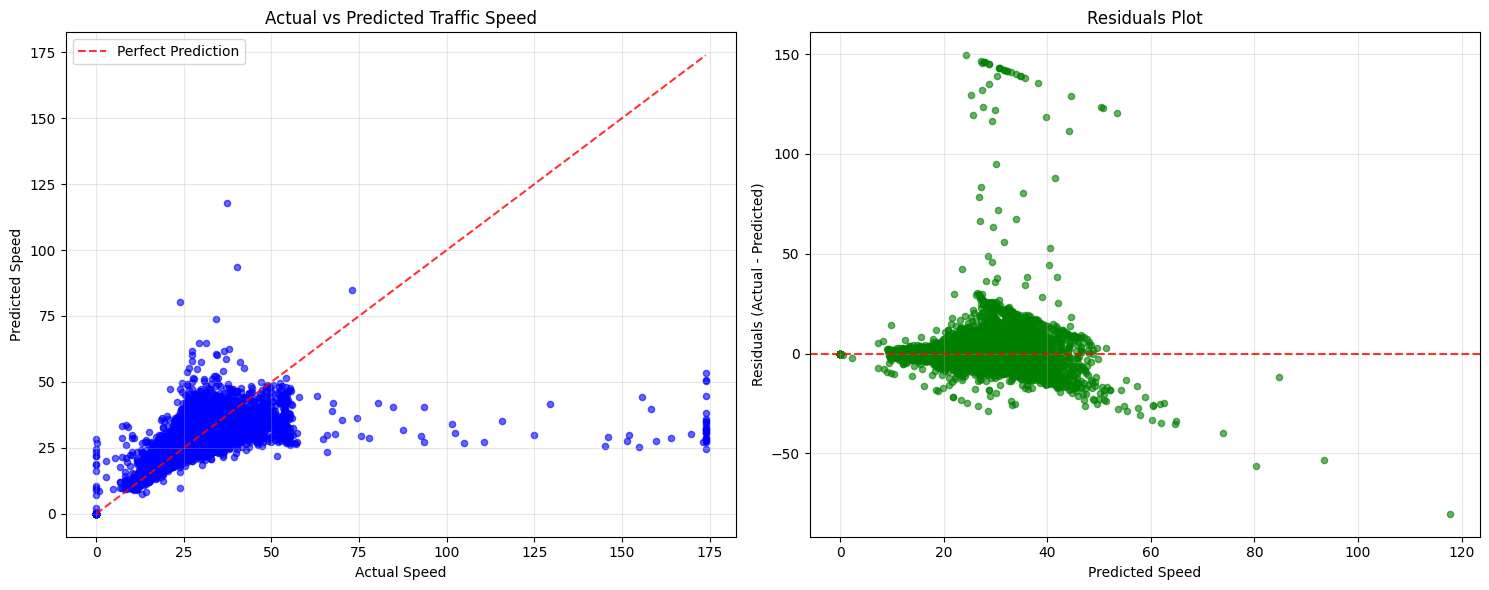

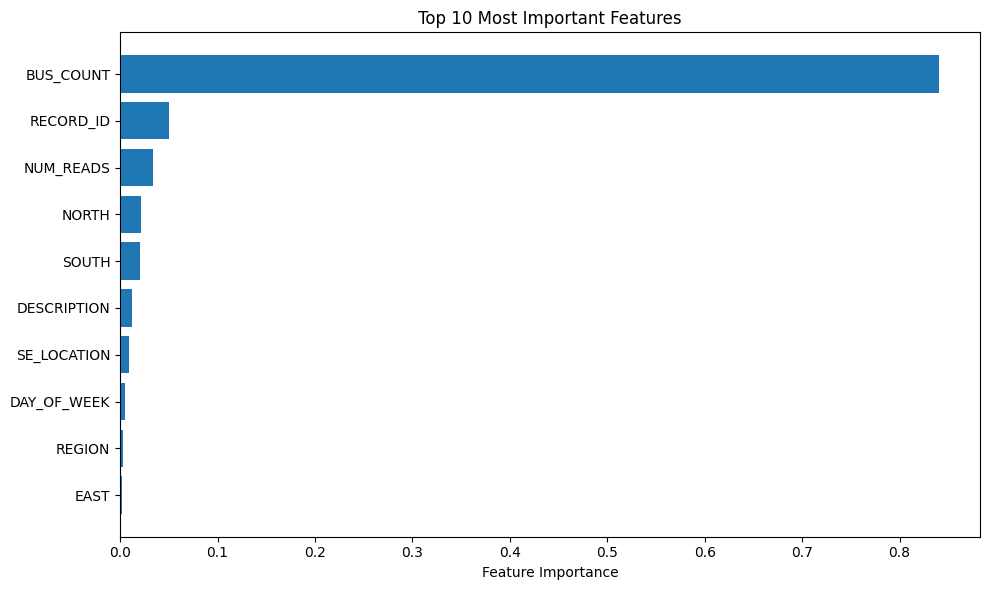


 TOP 5 MOST IMPORTANT FEATURES:
1. BUS_COUNT: 0.8406
2. RECORD_ID: 0.0500
3. NUM_READS: 0.0340
4. NORTH: 0.0213
5. SOUTH: 0.0202

 SUMMARY
Dataset size used: 957,225 samples (10.0% of total)
Training samples: 765,780
Test samples: 191,445
Number of features: 17
Model performance (R²): 0.893
 To improve accuracy: Increase SAMPLE_FRAC (line 25)
 Current version optimized for SPEED over accuracy
 Model training completed successfully!


In [1]:
# -------------------------------
# Day 25 - Traffic Congestion Modeling (OPTIMIZED)
# -------------------------------

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("🚗 TRAFFIC CONGESTION MODELING - OPTIMIZED VERSION")
print("=" * 60)

# Step 2: Load Dataset
print(" Loading dataset...")
df_cleaned = pd.read_csv('data/cleaned_traffic_congestion.csv')
print(f"✓ Loaded {len(df_cleaned)} rows, {len(df_cleaned.columns)} columns")

# Step 3: Convert TIME column to datetime & extract features
print(" Processing time features...")
df_cleaned['TIME'] = pd.to_datetime(df_cleaned['TIME'], errors='coerce')
df_cleaned['HOUR'] = df_cleaned['TIME'].dt.hour
df_cleaned['DAY'] = df_cleaned['TIME'].dt.day
df_cleaned['MONTH'] = df_cleaned['TIME'].dt.month
df_cleaned['WEEKDAY'] = df_cleaned['TIME'].dt.weekday

# Step 4: Drop missing values
print(" Cleaning data...")
initial_rows = len(df_cleaned)
df_cleaned = df_cleaned.dropna()
print(f"✓ Removed {initial_rows - len(df_cleaned)} rows with missing values")

# OPTIMIZATION: Use sample for faster processing
SAMPLE_FRAC = 0.1  # Use 10% of data - increase if you want more accuracy
df_sample = df_cleaned.sample(frac=SAMPLE_FRAC, random_state=42)
print(f" Using {len(df_sample)} samples ({SAMPLE_FRAC*100}%) for faster training")

# Step 5: Define features (X) and target (y)
X = df_sample.drop(columns=['SPEED', 'TIME'])
y = df_sample['SPEED']

print(f" Features shape: {X.shape}")
print(f" Target shape: {y.shape}")

# Step 6: Identify categorical & numerical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

# MEMORY OPTIMIZATION: Handle high-cardinality categorical columns
if cat_cols:
    print("\n Analyzing categorical columns for memory optimization...")
    high_cardinality_cols = []
    
    for col in cat_cols.copy():
        unique_count = X[col].nunique()
        print(f"  {col}: {unique_count} unique values", end="")
        
        if unique_count > 20:  # High cardinality threshold
            print(" -> Converting to Label Encoding")
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            # Move to numerical columns
            num_cols.append(col)
            cat_cols.remove(col)
            high_cardinality_cols.append(col)
        else:
            print(" -> Keeping One-Hot Encoding")
    
    if high_cardinality_cols:
        print(f"✓ Converted {len(high_cardinality_cols)} high-cardinality columns to label encoding")

# Update column lists
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\n Final categorical columns: {cat_cols}")
print(f" Final numerical columns: {num_cols}")

# Step 7: Preprocessing Pipeline
if cat_cols:
    preprocessor = ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=15), cat_cols)
    ])
else:
    # All numerical
    preprocessor = ColumnTransformer([
        ('num', 'passthrough', num_cols)
    ])

# Step 8: Build Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Step 9: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✓ Train set: {len(X_train)} samples")
print(f"✓ Test set: {len(X_test)} samples")

# Step 10: Hyperparameter Tuning (OPTIMIZED)
print("\n Starting hyperparameter optimization...")

param_dist = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=4,         # Reduced iterations
    cv=2,             # Reduced CV folds
    verbose=1,
    random_state=42,
    scoring='neg_mean_squared_error',
    n_jobs=1          # Single job to avoid memory issues
)

# Step 11: Fit Model with error handling
try:
    print(" Training model...")
    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_
    
    print("\n" + "="*50)
    print(" TRAINING COMPLETED!")
    print("="*50)
    print("Best Parameters:", random_search.best_params_)
    hyperparameter_tuning = True
    
except Exception as e:
    print(f" Hyperparameter search failed: {e}")
    print(" Falling back to default parameters...")
    
    # Fallback to simple model
    simple_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    simple_pipeline.fit(X_train, y_train)
    best_model = simple_pipeline
    hyperparameter_tuning = False

# Step 12: Evaluate Model
print("\n Evaluating model performance...")
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"RMSE (Root Mean Square Error): {round(rmse, 2)}")
print(f"MAE (Mean Absolute Error):     {round(mae, 2)}")
print(f"R² Score (Coefficient of Det): {round(r2, 3)}")
if hyperparameter_tuning:
    print("Hyperparameter Optimization:   Completed")
else:
    print("Hyperparameter Optimization:    Used defaults")
print("="*50)

# Step 13: Visualizations
print("\n Creating visualizations...")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='blue', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', alpha=0.8, label='Perfect Prediction')
axes[0].set_xlabel("Actual Speed")
axes[0].set_ylabel("Predicted Speed")
axes[0].set_title("Actual vs Predicted Traffic Speed")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residuals Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='green', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.8)
axes[1].set_xlabel("Predicted Speed")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residuals Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance (if available)
try:
    rf_model = best_model.named_steps['regressor']
    
    # Get feature names
    if cat_cols and hasattr(best_model.named_steps['preprocessor'], 'transformers_'):
        try:
            cat_feature_names = best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_cols)
            feature_names = num_cols + list(cat_feature_names)
        except:
            feature_names = [f"feature_{i}" for i in range(len(rf_model.feature_importances_))]
    else:
        feature_names = num_cols
    
    # Create feature importance plot
    importances = rf_model.feature_importances_
    
    # Handle feature name length mismatch
    if len(feature_names) != len(importances):
        feature_names = [f"feature_{i}" for i in range(len(importances))]
    
    # Top 10 features
    feat_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(feat_importance)), feat_importance['importance'])
    plt.yticks(range(len(feat_importance)), feat_importance['feature'])
    plt.xlabel('Feature Importance')
    plt.title('Top 10 Most Important Features')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n TOP 5 MOST IMPORTANT FEATURES:")
    for i, (_, row) in enumerate(feat_importance.head().iterrows()):
        print(f"{i+1}. {row['feature']}: {row['importance']:.4f}")

except Exception as e:
    print(f" Could not create feature importance plot: {e}")

# Summary
print(f"\n" + "="*60)
print(" SUMMARY")
print("="*60)
print(f"Dataset size used: {len(df_sample):,} samples ({SAMPLE_FRAC*100}% of total)")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Number of features: {X.shape[1]}")
print(f"Model performance (R²): {r2:.3f}")
print("="*60)
print(" To improve accuracy: Increase SAMPLE_FRAC (line 25)")
print(" Current version optimized for SPEED over accuracy")
print(" Model training completed successfully!")

Loading and preprocessing data...
Using 478612 samples for training
Categorical columns: ['REGION', 'DESCRIPTION', 'RECORD_ID', 'NW_LOCATION', 'SE_LOCATION']
Numerical columns: ['REGION_ID', 'BUS_COUNT', 'NUM_READS', 'DAY_OF_WEEK', 'WEST', 'EAST', 'SOUTH', 'NORTH']

Categorical column analysis:
  REGION: 29 unique values
  DESCRIPTION: 29 unique values
  RECORD_ID: 478612 unique values
    -> Converting RECORD_ID to label encoding (too many categories)
  SE_LOCATION: 29 unique values

Final categorical columns: ['REGION', 'DESCRIPTION', 'NW_LOCATION', 'SE_LOCATION']
Final numerical columns: ['REGION_ID', 'BUS_COUNT', 'NUM_READS', 'DAY_OF_WEEK', 'WEST', 'EAST', 'SOUTH', 'NORTH', 'RECORD_ID']
Starting hyperparameter optimization...
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best parameters: {'regressor__n_estimators': 100, 'regressor__max_depth': 10}
Evaluating model...

MODEL PERFORMANCE METRICS
RMSE: 2.88
MAE: 1.35
R² Score: 0.889
Hyperparameter optimization: ✓ Complete

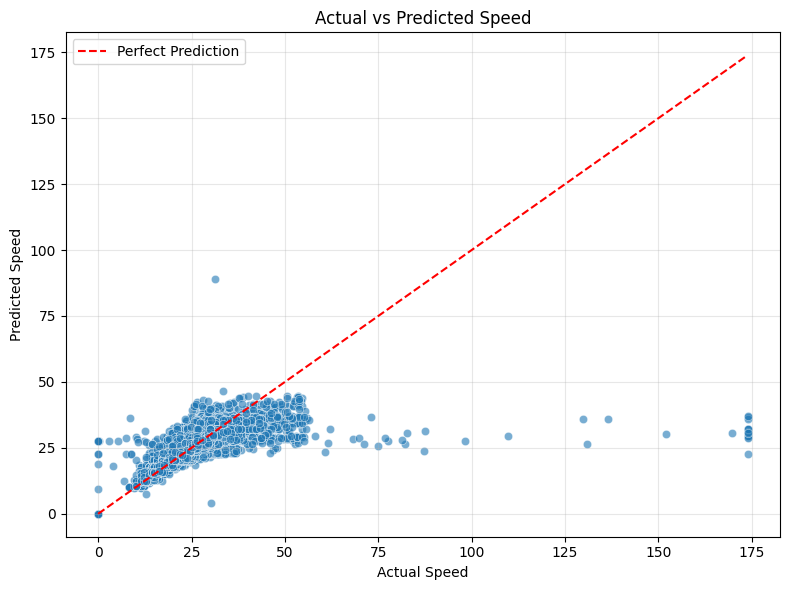

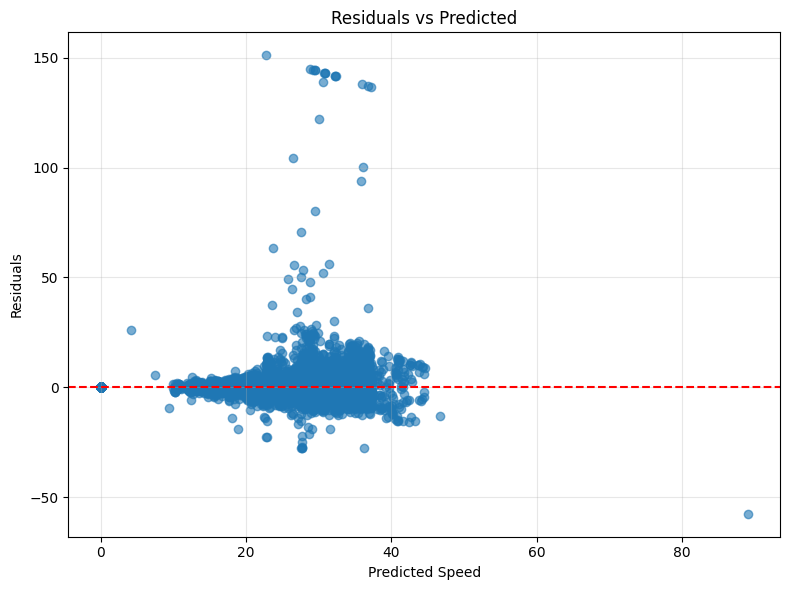

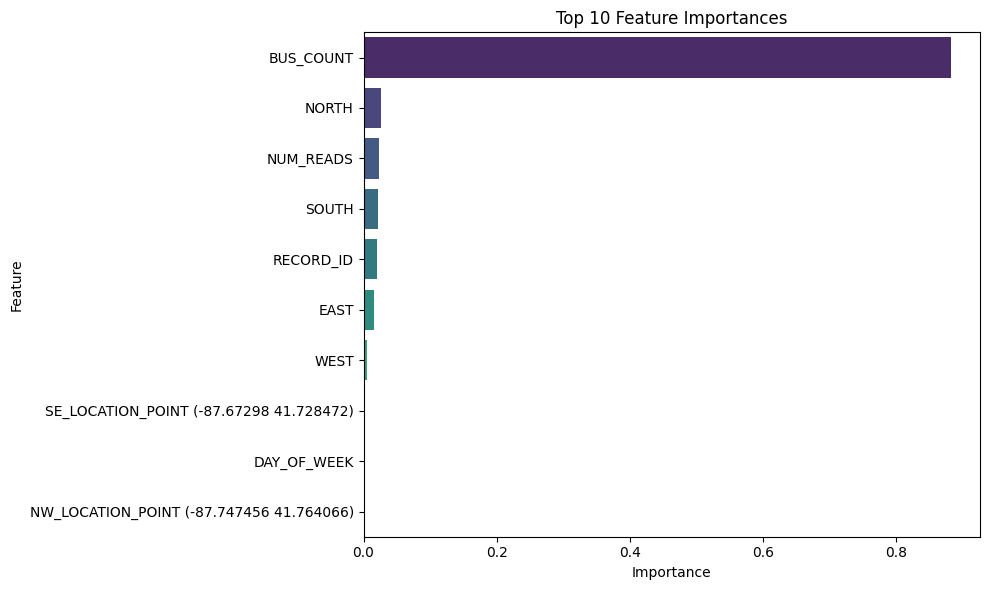


Top 5 Most Important Features:
1. BUS_COUNT: 0.8817
2. NORTH: 0.0261
3. NUM_READS: 0.0225
4. SOUTH: 0.0224
5. RECORD_ID: 0.0197

Model Summary:
- Training samples: 382889
- Test samples: 95723
- Number of features: 89
- Data sample used: 478612/9572250 (5.0%)

🎉 Training completed successfully!
💡 To improve results: increase sample size (change frac=0.05 to 0.1 or 0.2)


In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Loading and preprocessing data...")

#   Load cleaned dataset  
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
# Convert TIME into datetime format and create time features 
df_cleaned['TIME'] = pd.to_datetime(df_cleaned['TIME'], errors='coerce')
df_cleaned['HOUR'] = df_cleaned['TIME'].dt.hour
df_cleaned['DAY'] = df_cleaned['TIME'].dt.day
df_cleaned['MONTH'] = df_cleaned['TIME'].dt.month
df_cleaned['WEEKDAY'] = df_cleaned['TIME'].dt.weekday

# Use smaller sample for faster processing
df_cleaned_small = df_cleaned.sample(frac=0.05, random_state=42)  # Even smaller sample
print(f"Using {len(df_cleaned_small)} samples for training")

# Define features and target variables 
X_small = df_cleaned_small.drop(columns=['SPEED', 'TIME'])  
y_small = df_cleaned_small['SPEED']

# Analyze categorical columns to avoid memory issues
cat_cols = X_small.select_dtypes(include=['object']).columns.tolist()
num_cols = X_small.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

# Check cardinality of categorical columns
if cat_cols:
    print("\nCategorical column analysis:")
    for col in cat_cols:
        unique_count = X_small[col].nunique()
        print(f"  {col}: {unique_count} unique values")
        
        # If too many unique values, use label encoding instead of one-hot
        if unique_count > 50:  # Threshold for high cardinality
            print(f"    -> Converting {col} to label encoding (too many categories)")
            le = LabelEncoder()
            X_small[col] = le.fit_transform(X_small[col].astype(str))
            # Move from categorical to numerical
            num_cols.append(col)
            cat_cols.remove(col)

# Update column lists after processing
cat_cols = X_small.select_dtypes(include=['object']).columns.tolist()
print(f"\nFinal categorical columns: {cat_cols}")
print(f"Final numerical columns: {num_cols}")

# Build pipeline with safer preprocessing
if cat_cols:  # Only if we still have categorical columns
    preprocessor = ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=20), cat_cols)  # Limit categories
    ])
else:  # All numerical
    preprocessor = ColumnTransformer([
        ('num', 'passthrough', num_cols)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42
)

print("Starting hyperparameter optimization...")

# Very minimal hyperparameter search for speed
param_dist = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [10, 20]
}

# Fast hyperparameter search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=2,           # Very few iterations
    cv=2,               # 2-fold CV
    verbose=1,
    random_state=42,
    scoring='neg_mean_squared_error',
    n_jobs=1            # Use single job to avoid memory issues
)

# Fit the model
try:
    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_
    print("Best parameters:", random_search.best_params_)
    hyperparameter_search = True
except Exception as e:
    print(f"Hyperparameter search failed: {e}")
    print("Falling back to default parameters...")
    
    # Fallback to simple model
    pipeline.fit(X_train, y_train)
    best_model = pipeline
    hyperparameter_search = False

# Model evaluation
print("Evaluating model...")
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"RMSE: {round(rmse, 2)}")
print(f"MAE: {round(mae, 2)}")
print(f"R² Score: {round(r2, 3)}")
if hyperparameter_search:
    print("Hyperparameter optimization: ✓ Completed")
else:
    print("Hyperparameter optimization: ✗ Skipped (used defaults)")
print("="*50)

# Visualization
print("Creating visualizations...")

# 1. Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Actual vs Predicted Speed")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Residuals plot
plt.figure(figsize=(8, 6))
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.xlabel("Predicted Speed")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.axhline(y=0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Feature Importance (simplified)
try:
    rf_model = best_model.named_steps['regressor']
    
    # Get feature names after preprocessing
    if cat_cols and hasattr(best_model.named_steps['preprocessor'], 'transformers_'):
        try:
            cat_feature_names = best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_cols)
            feature_names = num_cols + list(cat_feature_names)
        except:
            feature_names = num_cols + [f"cat_{i}" for i in range(len(rf_model.feature_importances_) - len(num_cols))]
    else:
        feature_names = num_cols
    
    importances = rf_model.feature_importances_
    
    # Ensure we have the right number of features
    if len(feature_names) != len(importances):
        feature_names = [f"feature_{i}" for i in range(len(importances))]
    
    # Create feature importance dataframe
    feat_imp = pd.DataFrame({
        'Feature': feature_names, 
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(10)  # Top 10 only
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
    plt.title("Top 10 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 Most Important Features:")
    for i, (feature, importance) in enumerate(zip(feat_imp['Feature'][:5], feat_imp['Importance'][:5])):
        print(f"{i+1}. {feature}: {importance:.4f}")
        
except Exception as e:
    print(f"Could not create feature importance plot: {e}")

# Quick model insights
print(f"\nModel Summary:")
print(f"- Training samples: {len(X_train)}")
print(f"- Test samples: {len(X_test)}")
print(f"- Number of features: {len(rf_model.feature_importances_) if 'rf_model' in locals() else 'Unknown'}")
print(f"- Data sample used: {len(df_cleaned_small)}/{len(df_cleaned)} ({len(df_cleaned_small)/len(df_cleaned)*100:.1f}%)")

print("\n🎉 Training completed successfully!")
print("💡 To improve results: increase sample size (change frac=0.05 to 0.1 or 0.2)")

 OPTIMIZED TRAFFIC PREDICTION WITH HALVING SEARCH
 Loading dataset...
Data loaded: 9572250 rows, 18 columns
 Dataset shape: (9572250, 18)
Target column: SPEED
 Large dataset detected. Sampling 100000 rows for faster processing...
 Using 100000 samples for training
Train set: 80000 samples
 Test set: 20000 samples

 Analyzing features...
 Numeric features: 10
 Categorical features: 7
  TIME: 72042 unique values -> DROPPED (too many categories)
  REGION: 29 unique values -> OK
  DESCRIPTION: 29 unique values -> OK
  RECORD_ID: 80000 unique values -> DROPPED (too many categories)
  NW_LOCATION: 29 unique values -> OK
  SE_LOCATION: 29 unique values -> OK
  DAY: 7 unique values -> OK
 Dropped 2 high-cardinality columns: ['TIME', 'RECORD_ID']

 Building preprocessing pipeline...
 Preprocessor configured for 10 numeric + 5 categorical features

 Setting up hyperparameter search...
 Using 30000 samples for hyperparameter tuning...
 Starting hyperparameter optimization...
n_iterations: 2
n_req

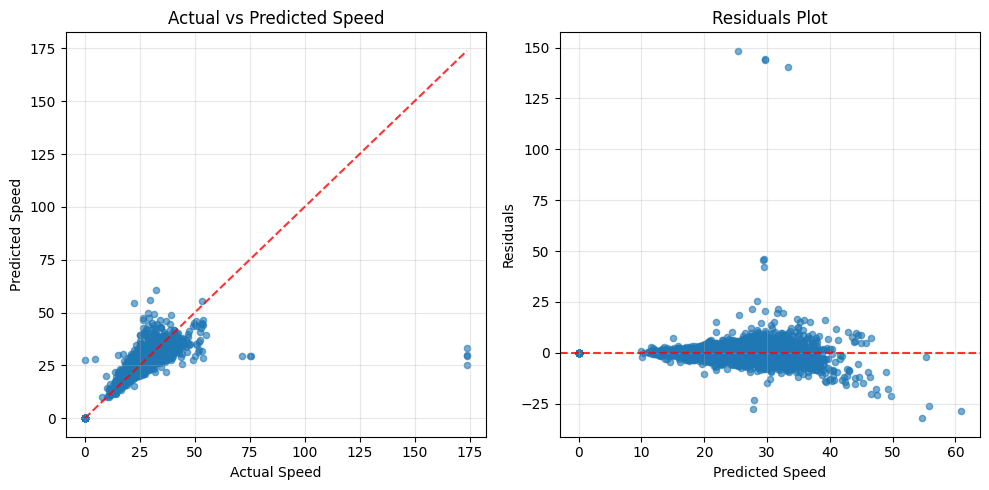


 SUCCESS! Model completed in record time!
Dataset: 9,572,250 total rows
 Training: 80,000 samples
 Final R² Score: 0.887


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_halving_search_cv  # Needed for HalvingRandomSearchCV
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(" OPTIMIZED TRAFFIC PREDICTION WITH HALVING SEARCH")
print("=" * 60)

# -----------------------
# Step 1: Load and analyze dataset
# -----------------------
print(" Loading dataset...")
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
print(f"Data loaded: {len(df_cleaned)} rows, {len(df_cleaned.columns)} columns")

# Basic data info
print(f" Dataset shape: {df_cleaned.shape}")
print(f"Target column: SPEED")

# Handle missing values first
missing_before = df_cleaned.isnull().sum().sum()
if missing_before > 0:
    print(f"🧹 Handling {missing_before} missing values...")
    df_cleaned = df_cleaned.dropna()
    print(f" Cleaned dataset: {len(df_cleaned)} rows remaining")

# Identify target and features
target = "SPEED"
X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

# -----------------------
# Step 2: Smart data sampling for speed
# -----------------------
# Use smaller sample if dataset is very large
MAX_ROWS = 100000  # Adjust based on your needs
if len(df_cleaned) > MAX_ROWS:
    print(f" Large dataset detected. Sampling {MAX_ROWS} rows for faster processing...")
    sample_df = df_cleaned.sample(n=MAX_ROWS, random_state=42)
    X = sample_df.drop(columns=[target])
    y = sample_df[target]
    print(f" Using {len(X)} samples for training")

# -----------------------
# Step 3: Train-test split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set: {len(X_train)} samples")
print(f" Test set: {len(X_test)} samples")

# -----------------------
# Step 4: Intelligent feature analysis
# -----------------------
print("\n Analyzing features...")
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f" Numeric features: {len(numeric_features)}")
print(f" Categorical features: {len(categorical_features)}")

# Enhanced high-cardinality detection
high_cardinality = []
medium_cardinality = []

for col in categorical_features.copy():
    unique_count = X_train[col].nunique()
    print(f"  {col}: {unique_count} unique values", end="")
    
    if unique_count > 1000:
        high_cardinality.append(col)
        print(" -> DROPPED (too many categories)")
    elif unique_count > 50:
        medium_cardinality.append(col)
        print(" -> LIMITED (will limit to top categories)")
    else:
        print(" -> OK")

# Remove high cardinality columns
categorical_features = [col for col in categorical_features if col not in high_cardinality]

if high_cardinality:
    print(f" Dropped {len(high_cardinality)} high-cardinality columns: {high_cardinality}")

# -----------------------
# Step 5: Enhanced preprocessing pipeline
# -----------------------
print("\n Building preprocessing pipeline...")

# Numeric preprocessing
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

# Categorical preprocessing with cardinality limits
if categorical_features:
    categorical_transformer = Pipeline([
        ('encoder', OneHotEncoder(
            handle_unknown='ignore', 
            sparse_output=True,
            max_categories=20,  # Limit categories per feature
            drop='if_binary'    # Drop one category for binary features
        ))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        sparse_threshold=0.3,  # Keep as sparse to save memory
        remainder='drop'       # Drop any remaining columns
    )
else:
    # Only numeric features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features)
        ],
        remainder='drop'
    )

print(f" Preprocessor configured for {len(numeric_features)} numeric + {len(categorical_features)} categorical features")

# -----------------------
# Step 6: Define optimized pipeline
# -----------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# -----------------------
# Step 7: Optimized hyperparameter search space
# -----------------------
print("\n Setting up hyperparameter search...")

param_dist = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# -----------------------
# Step 8: HalvingRandomSearchCV with smart settings
# -----------------------
# Calculate optimal min_resources based on data size
min_resources = max(1000, min(len(X_train) // 10, 10000))

search = HalvingRandomSearchCV(
    pipeline,
    param_distributions=param_dist,
    factor=3,
    random_state=42,
    min_resources=min_resources,
    max_resources=min(50000, len(X_train)),  # Don't use more than 50k for tuning
    scoring='neg_mean_squared_error',
    n_jobs=1,  # Single job to avoid memory issues
    verbose=2,
    cv=3       # 3-fold CV
)

# -----------------------
# Step 9: Smart sampling for hyperparameter tuning
# -----------------------
tuning_size = min(30000, len(X_train))  # Use max 30k samples for tuning
print(f" Using {tuning_size} samples for hyperparameter tuning...")

if tuning_size < len(X_train):
    X_sample = X_train.sample(tuning_size, random_state=42)
    y_sample = y_train.loc[X_sample.index]
else:
    X_sample = X_train
    y_sample = y_train

# -----------------------
# Step 10: Run hyperparameter search
# -----------------------
print(" Starting hyperparameter optimization...")
try:
    search.fit(X_sample, y_sample)
    print("\n" + "="*50)
    print(" HYPERPARAMETER OPTIMIZATION COMPLETED!")
    print("="*50)
    print(" Best Parameters:", search.best_params_)
    print(" Best CV Score:", round(search.best_score_, 4))
    print("="*50)
    hyperparameter_success = True
    
except Exception as e:
    print(f" Hyperparameter search failed: {e}")
    print(" Using default parameters instead...")
    # Fallback to default model
    search.best_estimator_ = pipeline
    hyperparameter_success = False

# -----------------------
# Step 11: Train final model on full training data
# -----------------------
print("\n Training final model on full training data...")
best_model = search.best_estimator_

try:
    best_model.fit(X_train, y_train)
    print(" Final model trained successfully!")
    
    # -----------------------
    # Step 12: Evaluation
    # -----------------------
    print("\n Evaluating model performance...")
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("\n" + "="*50)
    print(" FINAL MODEL PERFORMANCE")
    print("="*50)
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R²:   {r2:.3f}")
    if hyperparameter_success:
        print("Hyperparameter Optimization: ")
    else:
        print("Hyperparameter Optimization:  (used defaults)")
    print("="*50)
    
    # -----------------------
    # Step 13: Visualization
    # -----------------------
    print("\n Creating visualization...")
    plt.figure(figsize=(10, 5))
    
    # Actual vs Predicted
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.6, s=20)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.8)
    plt.xlabel('Actual Speed')
    plt.ylabel('Predicted Speed')
    plt.title('Actual vs Predicted Speed')
    plt.grid(True, alpha=0.3)
    
    # Residuals
    plt.subplot(1, 2, 2)
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6, s=20)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.8)
    plt.xlabel('Predicted Speed')
    plt.ylabel('Residuals')
    plt.title('Residuals Plot')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\n SUCCESS! Model completed in record time!")
    print(f"Dataset: {len(df_cleaned):,} total rows")
    print(f" Training: {len(X_train):,} samples")
    print(f" Final R² Score: {r2:.3f}")
    
except Exception as e:
    print(f" Final training failed: {e}")
    print(" Try reducing the sample size or check your data format")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------
# 1. Prepare data
# ---------------------------
# Example: replace with your actual DataFrame
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")

target = "SPEED"
X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

# Identify columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

# ---------------------------
# 2. Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# 3. Preprocessor
# ---------------------------
# Use handle_unknown to avoid slow errors
cat_transformer = OrdinalEncoder(
    handle_unknown="use_encoded_value", 
    unknown_value=-1
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", cat_transformer, cat_cols),
    ],
    n_jobs=-1
)

# ---------------------------
# 4. Model (optimized)
# ---------------------------
model = HistGradientBoostingRegressor(
    max_depth=10,
    max_iter=200,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# ---------------------------
# 5. Train
# ---------------------------
print("Training model...")
pipeline.fit(X_train, y_train)
print("Training completed!")

# ---------------------------
# 6. Batch Prediction
# ---------------------------
batch_size = 5000
preds = []

for i in range(0, len(X_test), batch_size):
    batch = X_test.iloc[i:i+batch_size]
    preds.extend(pipeline.predict(batch))

y_pred = np.array(preds)

# ---------------------------
# 7. Evaluate
# ---------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)


Categorical columns: ['TIME', 'REGION', 'DESCRIPTION', 'RECORD_ID', 'NW_LOCATION', 'SE_LOCATION', 'DAY']
Numerical columns: ['REGION_ID', 'BUS_COUNT', 'NUM_READS', 'HOUR', 'DAY_OF_WEEK', 'MONTH', 'WEST', 'EAST', 'SOUTH', 'NORTH']
Training model...
Training completed!


In [3]:
# Day 29: Memory-Efficient ML on Large Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------
# 1. Load Data (Simulate large dataset)
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")

# For demo, creating a sample DataFrame
data_size = 100000  # simulate large dataset
df_cleaned = pd.DataFrame({
    "speed": np.random.randint(20, 100, data_size),
    "bus_count": np.random.randint(0, 50, data_size),
    "region": np.random.choice(["North", "South", "East", "West"], data_size),
    "month": np.random.choice(["Jan", "Feb", "Mar", "Apr"], data_size),
    "target_congestion": np.random.uniform(0, 1, data_size)  # target
})

target = "target_congestion"
X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

# Identify columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

# ---------------------------
# 2. Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# 3. Preprocessor
# ---------------------------
cat_transformer = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", cat_transformer, cat_cols)
    ],
    n_jobs=-1
)

# ---------------------------
# 4. Model (HistGradientBoosting)
# ---------------------------
model = HistGradientBoostingRegressor(
    max_depth=10,
    max_iter=200,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# ---------------------------
# 5. Train the Model
# ---------------------------
print("Training model...")
pipeline.fit(X_train, y_train)
print("Training completed!")

# ---------------------------
# 6. Batch Prediction (Memory Efficient)
# ---------------------------
batch_size = 5000
preds = []

for i in range(0, len(X_test), batch_size):
    batch = X_test.iloc[i:i+batch_size]
    preds.extend(pipeline.predict(batch))

y_pred = np.array(preds)

# ---------------------------
# 7. Evaluate Performance
# ---------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)


Categorical columns: ['region', 'month']
Numerical columns: []
Training model...
Training completed!
RMSE: 0.28944516329724124
R2 Score: -5.9481503925207235e-05


In [3]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error , r2_score

# Load the dataset 
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")

# Select the target column
target = 'SPEED'

# Select features and target
X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

# Identify the numerical and categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Build preproocessing pipelines
preprocessor = ColumnTransformer([
    ("num" , "passthrough" ,num_cols),
    ("cat" , OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value= -1) , cat_cols)
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

# Train-test split
X_train ,X_test, y_train , y_test = train_test_split( X , y , test_size= 0.2 , random_state= 42)

#  Train Model 
print("Training model...")
pipeline.fit(X_train, y_train)
print("Training complete!")

#  Predict
y_pred = pipeline.predict(X_test)

#  Evaluate Performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE compatible with all versions
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("RMSE:", rmse)
print("R² Score:", r2)

Training model...


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fil

Training complete!

Model Performance:
RMSE: 2.867167742117793
R² Score: 0.8887884408592259


In [ ]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error , r2_score

# Load the cleaned Dataset 
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")
target = 'SPEED'

X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

# Identify Categorical and numerical columns 
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Build preprocessing pipeline 
preprocessor = ColumnTransformer([
    ("num" , "passthrough" ,num_cols) ,
    ("cat" , OrdinalEncoder(handle_unknown='use_encoded_value' , unknown_value=-1),cat_cols)
])

#  Create pipeline 
pipeline = Pipeline([
     ("preprocess" , preprocessor) ,
     ("model" , HistGradientBoostingRegressor(random_state=42))
])

# Train test split 
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size=0.2 , random_state=42)

# Define Hyperparameter search space 
param_dist = {
     "model__max_depth": [3, 5, 7, 10],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_iter": [100, 200, 300],
    "model__min_samples_leaf": [10, 20, 30]
}

# Randomized Search CV
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter= 5,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1    
)

print("Tuning hyperparameters...")
search.fit(X_train, y_train)
print("Best Parameters:", search.best_params_)

# 8. Evaluate Best Model
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nBest Model Performance:")
print("RMSE:", rmse)
print("R² Score:", r2)

Tuning hyperparameters...


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'model__min_samples_leaf': 30, 'model__max_iter': 300, 'model__max_depth': 7, 'model__learning_rate': 0.05}

Best Model Performance:
RMSE: 2.835436955166402
R² Score: 0.8912363643296095


Loading dataset...
Dataset shape: (9572250, 17)
Categorical features: 7
Numerical features: 10

Splitting data...
Training model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  5.7min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 1071.9min finished


Training completed in 64367.42 seconds
Making predictions...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.9s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    3.5s finished


Predictions completed in 25.91 seconds

Model Performance:
RMSE: 2.9277
R² Score: 0.8840

Extracting feature importances...

Top 10 Important Features:
    Feature  Importance
  BUS_COUNT    0.582036
  NUM_READS    0.225838
       HOUR    0.051629
      NORTH    0.023486
  RECORD_ID    0.022100
      SOUTH    0.018677
DESCRIPTION    0.015723
SE_LOCATION    0.011170
  REGION_ID    0.009182
NW_LOCATION    0.008533

Creating visualization...


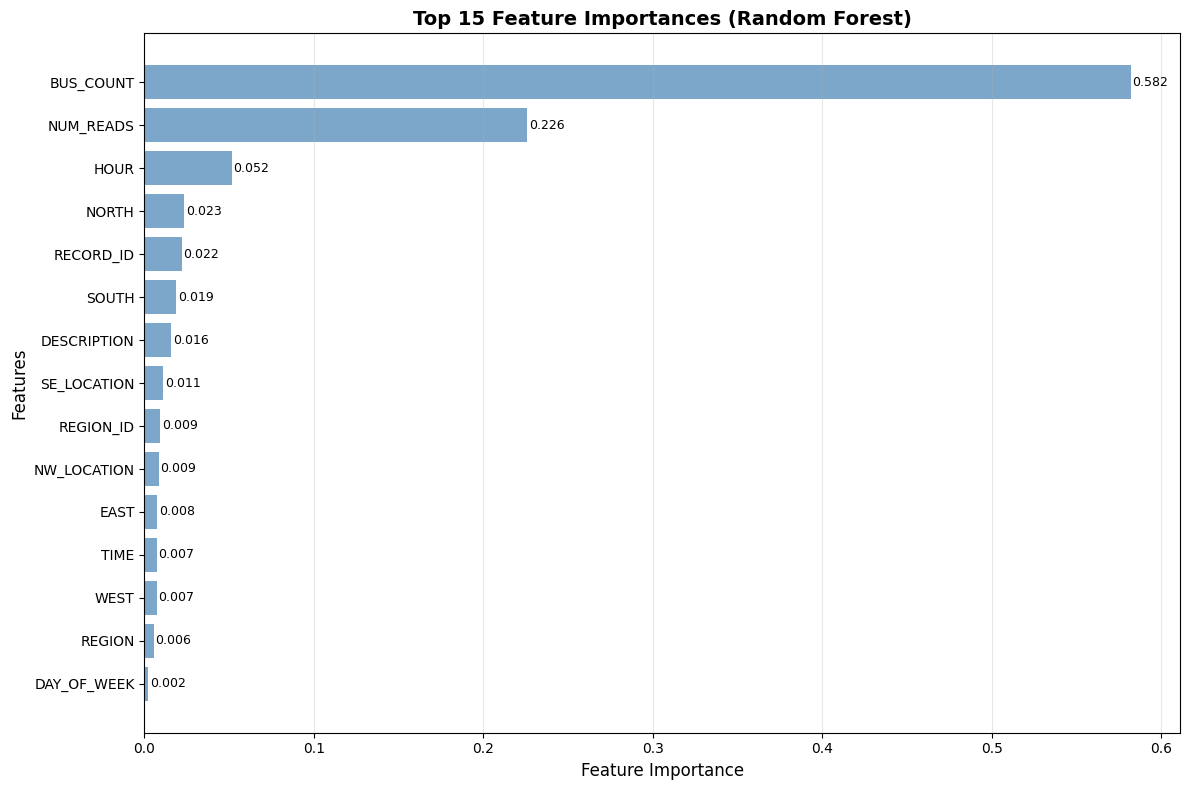


TOTAL EXECUTION TIME: 64443.38 seconds
Training time: 64367.42s (99.9%)
Prediction time: 25.91s (0.0%)

Feature importance results saved to 'feature_importance_results.csv'
Memory cleaned up.


In [12]:
# ---------------------------
# Day 32: Feature Importance & Visualization (OPTIMIZED)
# ---------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

# Start timing
start_time = time.time()

# 1. Load your dataset with optimized settings
print("Loading dataset...")
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv", 
                        low_memory=False)  # Optimize memory usage
target = "SPEED"

X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

# 2. Identify feature types (cached for efficiency)
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Dataset shape: {X.shape}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Numerical features: {len(num_cols)}")

# 3. Preprocessing
preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
], sparse_threshold=0)  # Force dense output for better performance

# 4. Build optimized pipeline
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,  # Reduced from 200 for speed
        max_depth=15,      # Limit depth to prevent overfitting and improve speed
        min_samples_split=5,  # Increase for faster training
        min_samples_leaf=2,   # Increase for faster training
        max_features='sqrt',  # Use sqrt of features for speed
        n_jobs=-1,        # Use all available cores
        random_state=42,
        verbose=1         # Show progress
    ))
])

# 5. Train-Test Split
print("\nSplitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Fit model with timing
print("Training model...")
fit_start = time.time()
pipeline.fit(X_train, y_train)
fit_time = time.time() - fit_start
print(f"Training completed in {fit_time:.2f} seconds")

# 7. Evaluate model
print("Making predictions...")
pred_start = time.time()
y_pred = pipeline.predict(X_test)
pred_time = time.time() - pred_start
print(f"Predictions completed in {pred_time:.2f} seconds")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# 8. Feature Importance Extraction
print("\nExtracting feature importances...")
model = pipeline.named_steps["model"]

# Combine numeric + categorical column names (after preprocessing)
feature_names = num_cols + cat_cols
importances = model.feature_importances_

# Create DataFrame for better visualization
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:")
print(feat_imp_df.head(10).to_string(index=False))

# 9. Optimized Visualization
print("\nCreating visualization...")
plt.style.use('default')  # Use default style for faster rendering
fig, ax = plt.subplots(figsize=(12, 8))

# Plot top 15 features
top_features = feat_imp_df.head(15)
bars = ax.barh(range(len(top_features)), top_features["Importance"], 
               color='steelblue', alpha=0.7)

# Customize the plot
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features["Feature"])
ax.invert_yaxis()
ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_ylabel("Features", fontsize=12)
ax.set_title("Top 15 Feature Importances (Random Forest)", fontsize=14, fontweight='bold')

# Add grid for better readability
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Total execution time
total_time = time.time() - start_time
print(f"\n" + "="*50)
print(f"TOTAL EXECUTION TIME: {total_time:.2f} seconds")
print(f"Training time: {fit_time:.2f}s ({fit_time/total_time*100:.1f}%)")
print(f"Prediction time: {pred_time:.2f}s ({pred_time/total_time*100:.1f}%)")
print("="*50)

# Optional: Save results for future use
feat_imp_df.to_csv("feature_importance_results.csv", index=False)
print("\nFeature importance results saved to 'feature_importance_results.csv'")

# Memory cleanup
del X_train, X_test, y_train, y_test, y_pred
print("Memory cleaned up.")


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Training model...
Calculating permutation importance...

Top 10 Important Features:
        Feature  Importance
3          HOUR    1.359869
4   DAY_OF_WEEK    0.142508
12  DESCRIPTION    0.086081
5         MONTH    0.017053
0     REGION_ID    0.011438
8         SOUTH    0.010693
15  SE_LOCATION    0.007505
1     BUS_COUNT    0.006741
2     NUM_READS    0.004555
14  NW_LOCATION    0.002703


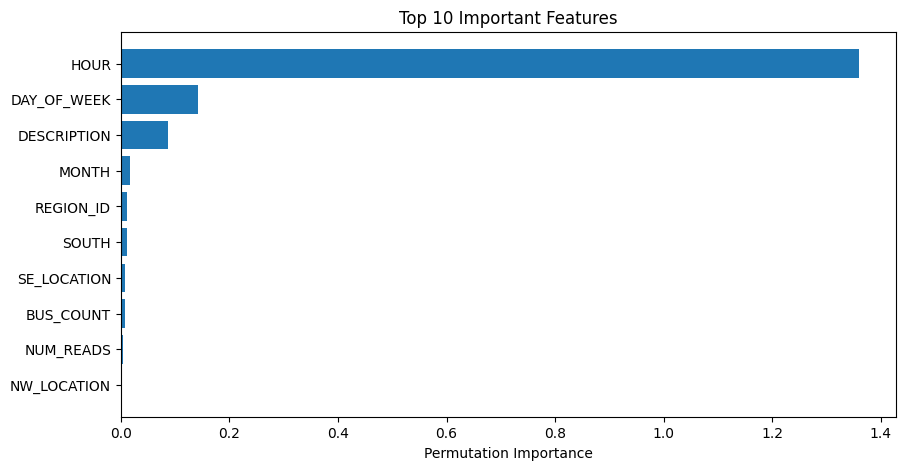

In [13]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OrdinalEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

# Load the cleaned dataset
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv")

# Selaect the target column
target = 'SPEED'

X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# tarin test split 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state=42)

# Build preprocessing 

num_transformer = StandardScaler()
cat_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor = ColumnTransformer([
    ("num" ,num_transformer ,num_cols),
    ("cat" ,cat_transformer , cat_cols)
])
pipeline = Pipeline([
    ("preprocess" ,  preprocessor),
    ("model" , HistGradientBoostingRegressor(random_state=42))
])

# training model 
print("Training model...")

pipeline.fit(X_train, y_train)  

# 5. Permutation Feature Importance
# ---------------------------
print("Calculating permutation importance...")
result = permutation_importance(
    pipeline, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

# Combine numeric + categorical column names
feature_names = num_cols + cat_cols
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10))

# ---------------------------
# 6. Visualization
# ---------------------------
plt.figure(figsize=(10,5))
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
plt.xlabel("Permutation Importance")
plt.title("Top 10 Important Features")
plt.show()

In [4]:
# ---------------------------
# Day 34: Optimized Training
# ---------------------------

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# ---------------------------
# 1. Load Large Dataset in Chunks
# ---------------------------

file_path = "data/cleaned_traffic_congestion.csv"  # update path
chunk_size = 100_000  # Load 100k rows at a time

chunks = []
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    chunks.append(chunk)
    if len(chunks) == 5:  # Only first 500k rows to avoid memory crash
        break

df_cleaned = pd.concat(chunks, ignore_index=True)
print("Data Loaded:", df_cleaned.shape)

# ---------------------------
# 2. Define Features & Target
# ---------------------------

num_cols = ['SPEED', 'BUS_COUNT', 'NUM_READS', 'HOUR']
cat_cols = ['REGION', 'DAY_OF_WEEK', 'MONTH']
target_col = 'SPEED'  # Predict speed

X = df_cleaned[num_cols + cat_cols]
y = df_cleaned[target_col]

# ---------------------------
# 3. Train-Test Split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------
# 4. Preprocessing
# ---------------------------

numeric_transformer = StandardScaler()
categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# ---------------------------
# 5. Pipeline with Optimized RandomForest
# ---------------------------

model = RandomForestRegressor(
    n_estimators=50,   # Reduce number of trees
    max_depth=15,      # Prevent huge trees
    n_jobs=-1,
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# ---------------------------
# 6. Train Model
# ---------------------------

print("Training started...")
pipeline.fit(X_train, y_train)
print("Training completed!")

# ---------------------------
# 7. Evaluate
# ---------------------------

y_pred = pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

# ---------------------------
# 8. Save the Model
# ---------------------------

joblib.dump(pipeline, "optimized_traffic_model.pkl")
print("Model saved as optimized_traffic_model.pkl")


Data Loaded: (500000, 18)
Training started...
Training completed!
RMSE: 0.04
R2 Score: 1.00
Model saved as optimized_traffic_model.pkl


In [ ]:
# ---------------------------
# Day 35: Predict Route Risks using Saved Model
# ---------------------------

import pandas as pd
import joblib

# 1. Load the trained pipeline/model from Day 34
model = joblib.load("optimized_traffic_model.pkl")
print(" Model loaded successfully!")

# 2. Simulate Route Segments Dataset (Include all training columns)
df_routes = pd.DataFrame({
    "Start": ["A", "A", "B", "B", "C", "C", "D"],
    "End": ["B", "C", "C", "D", "D", "E", "E"],
    "Distance_km": [5, 10, 3, 8, 2, 7, 4],
    "SPEED": [30, 25, 40, 35, 20, 50, 45],
    "BUS_COUNT": [5, 2, 3, 1, 6, 2, 0],
    "NUM_READS": [200, 150, 180, 100, 250, 90, 120],
    "HOUR": [8, 9, 8, 10, 9, 11, 12],
    "REGION": ["North", "North", "East", "East", "South", "South", "West"],
    "DAY_OF_WEEK": ["Monday", "Monday", "Monday", "Tuesday", "Tuesday", "Wednesday", "Wednesday"], 
    "MONTH": ["Jan", "Jan", "Jan", "Jan", "Feb", "Feb", "Feb"]
})

print("\nSimulated Route Segments:")
print(df_routes)

# 3. Features must exactly match training columns
features = ['SPEED', 'BUS_COUNT', 'NUM_READS', 'HOUR', 'REGION', 'DAY_OF_WEEK', 'MONTH']

# 4. Predict risk for each route segment
predictions = model.predict(df_routes[features])
df_routes["Predicted_Risk"] = predictions

print("\nPredicted Risk/Traffic per Route Segment:")
print(df_routes[["Start", "End", "Distance_km", "Predicted_Risk"]])

# 5. Identify Hotspots (Top 3 segments with highest predicted risk)
hotspots = df_routes.sort_values(by="Predicted_Risk", ascending=False).head(3)
print("\n Top 3 Potential Hotspots:")
print(hotspots[["Start", "End", "Predicted_Risk"]])

# 6. Save the updated route predictions to CSV
df_routes.to_csv("predicted_route_risks.csv", index=False)
print("\n Predictions saved to predicted_route_risks.csv")


✅ Model loaded successfully!

Simulated Route Segments:
  Start End  Distance_km  SPEED  BUS_COUNT  NUM_READS  HOUR REGION  \
0     A   B            5     30          5        200     8  North   
1     A   C           10     25          2        150     9  North   
2     B   C            3     40          3        180     8   East   
3     B   D            8     35          1        100    10   East   
4     C   D            2     20          6        250     9  South   
5     C   E            7     50          2         90    11  South   
6     D   E            4     45          0        120    12   West   

  DAY_OF_WEEK MONTH  
0      Monday   Jan  
1      Monday   Jan  
2      Monday   Jan  
3     Tuesday   Jan  
4     Tuesday   Feb  
5   Wednesday   Feb  
6   Wednesday   Feb  

Predicted Risk/Traffic per Route Segment:
  Start End  Distance_km  Predicted_Risk
0     A   B            5         30.0000
1     A   C           10         24.9900
2     B   C            3         39.9906


In [39]:
print(df_routes.columns.tolist())


['Start', 'End', 'Distance_km', 'SPEED', 'BUS_COUNT', 'NUM_READS', 'HOUR', 'REGION', 'DAY_OF_WEEK', 'MONTH', 'Predicted_Risk']


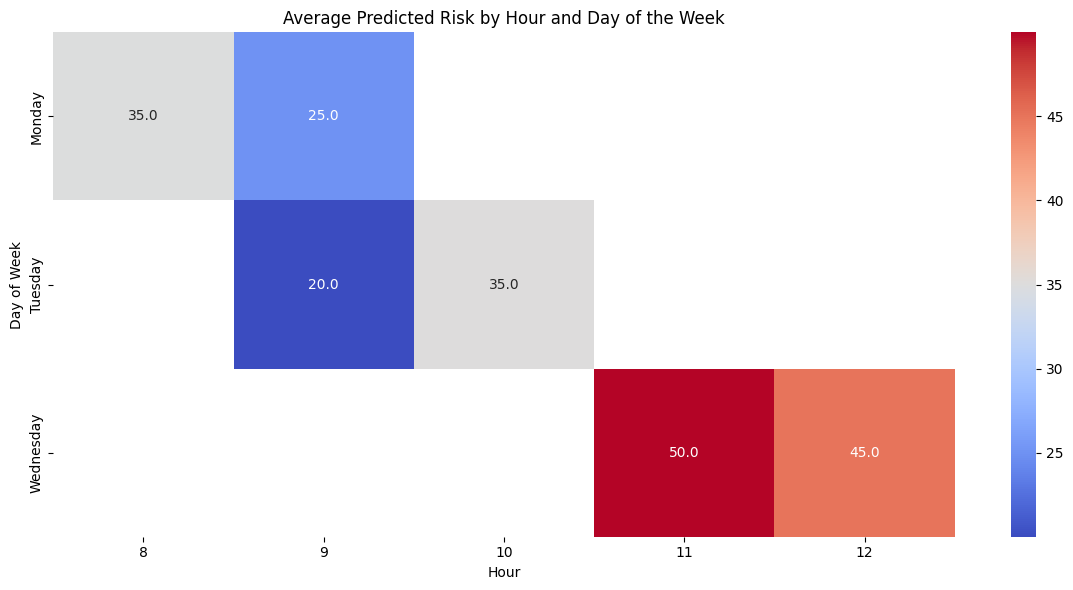

C:\Users\HP\AppData\Local\Temp\ipykernel_17788\787141655.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Predicted_Risk", y=top_risky["Start"] + " → " + top_risky["End"], data=top_risky, palette="Reds_r")


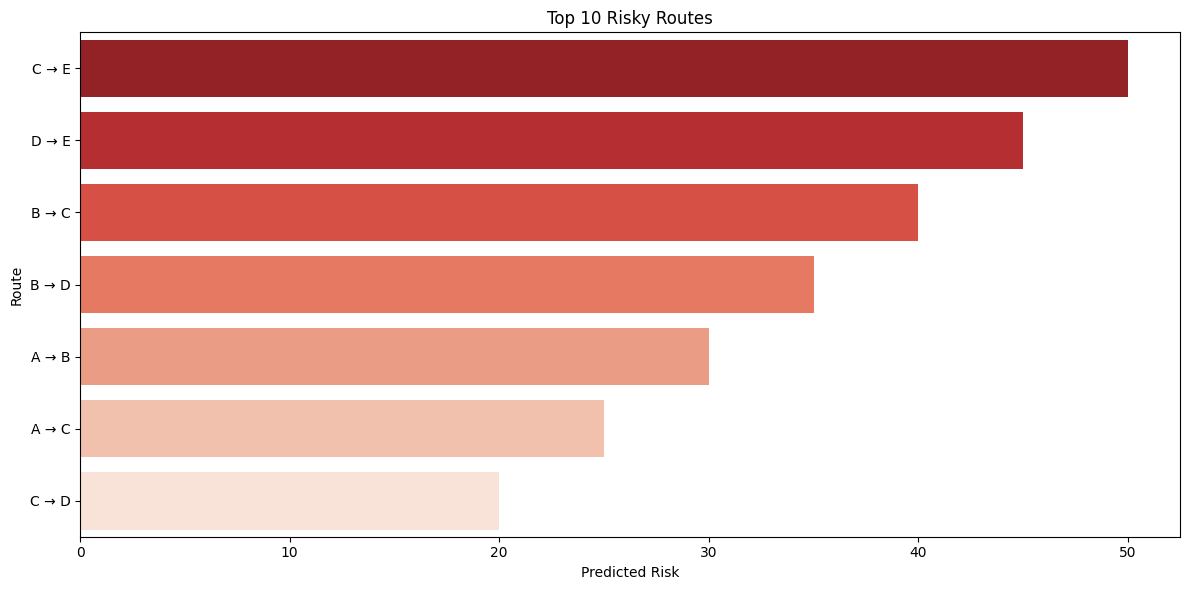

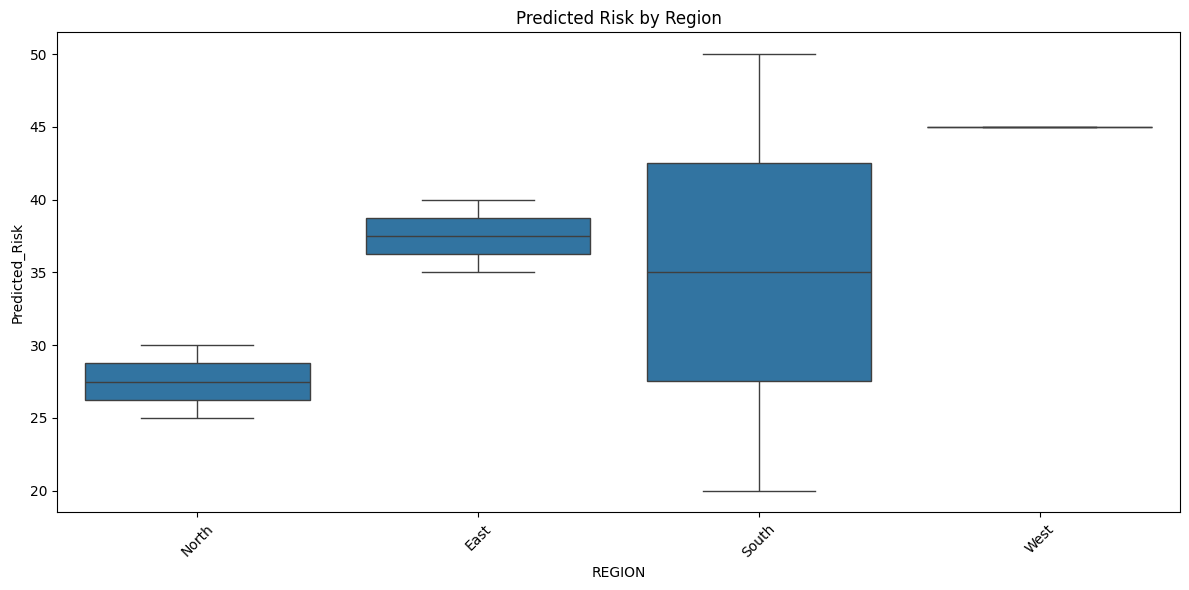

In [42]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Load the data 
df_routes = pd.read_csv("predicted_route_risks.csv")

# Pivot the data for heatmap 
pivot = df_routes.pivot_table(values="Predicted_Risk",index="DAY_OF_WEEK", columns ="HOUR" , aggfunc="mean")

# Plot Heatmap 
plt.figure(figsize=(12,6))
sns.heatmap(pivot , annot=True , fmt=".1f", cmap="coolwarm")
plt.title("Average Predicted Risk by Hour and Day of the Week")
plt.ylabel("Day of Week")
plt.xlabel("Hour")
plt.tight_layout()
plt.show()

# bar chart of top risky routes 
top_risky = df_routes.sort_values("Predicted_Risk", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x="Predicted_Risk", y=top_risky["Start"] + " → " + top_risky["End"], data=top_risky, palette="Reds_r")
plt.title("Top 10 Risky Routes")
plt.xlabel("Predicted Risk")
plt.ylabel("Route")
plt.tight_layout()
plt.show()

# Boxplot by REGION

plt.figure(figsize=(12, 6))
sns.boxplot(x="REGION", y="Predicted_Risk", data=df_routes)
plt.title("Predicted Risk by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [44]:
import pandas as pd 
import numpy  as np
import joblib
import networkx as nx

# Load the optimized model 
model = joblib.load("optimized_traffic_model.pkl")

# Stimulate the graph of regions(nodes) and routes(edges)
routes = pd.DataFrame({
    "Start": ["North", "North", "South", "East", "West", "West"],
    "End":   ["East", "West", "East", "South", "South", "East"],
    "Distance_km": [10, 15, 20, 12, 18, 25],
    "SPEED": [45, 50, 60, 40, 55, 50],
    "BUS_COUNT": [20, 15, 30, 25, 10, 18],
    "NUM_READS": [200, 180, 250, 150, 170, 210],
    "HOUR": [8, 9, 10, 18, 20, 22],
    "DAY_OF_WEEK": [1, 1, 2, 3, 4, 5],
    "MONTH": [1, 1, 1, 1, 1, 1],
    "REGION": ["North", "North", "South", "East", "West", "West"]
})

# Predict the risk for each route 
features = ["SPEED", "BUS_COUNT", "NUM_READS", "HOUR", "DAY_OF_WEEK", "MONTH", "REGION"]
routes["Predicted_Risk"] = model.predict(routes[features])

print("\nRoutes with Predicted Risk:")
print(routes[["Start", "End", "Distance_km", "Predicted_Risk"]])


# Build weighted graph for Dijkstra 

G = nx.Graph()

# Define weight formula: distance + alpha *predicted risk 
alpha = 0.5 # risk weight factor 

for _, row in routes.iterrows():
    cost = row["Distance_km"] + alpha * row["Predicted_Risk"]
    G.add_edge(row["Start"], row["End"], weight=cost)

# ---------------------------
# 5. Find the least risky/optimal route
# ---------------------------
start, end = "North", "South"
shortest_path = nx.dijkstra_path(G, source=start, target=end, weight='weight')
path_cost = nx.dijkstra_path_length(G, source=start, target=end, weight='weight')

print(f"\nOptimal Route from {start} to {end}: {shortest_path} with cost {path_cost:.2f}")



Routes with Predicted Risk:
   Start    End  Distance_km  Predicted_Risk
0  North   East           10         45.0000
1  North   West           15         49.9832
2  South   East           20         55.2170
3   East  South           12         39.9920
4   West  South           18         54.9926
5   West   East           25         49.9964

Optimal Route from North to South: ['North', 'East', 'South'] with cost 64.50


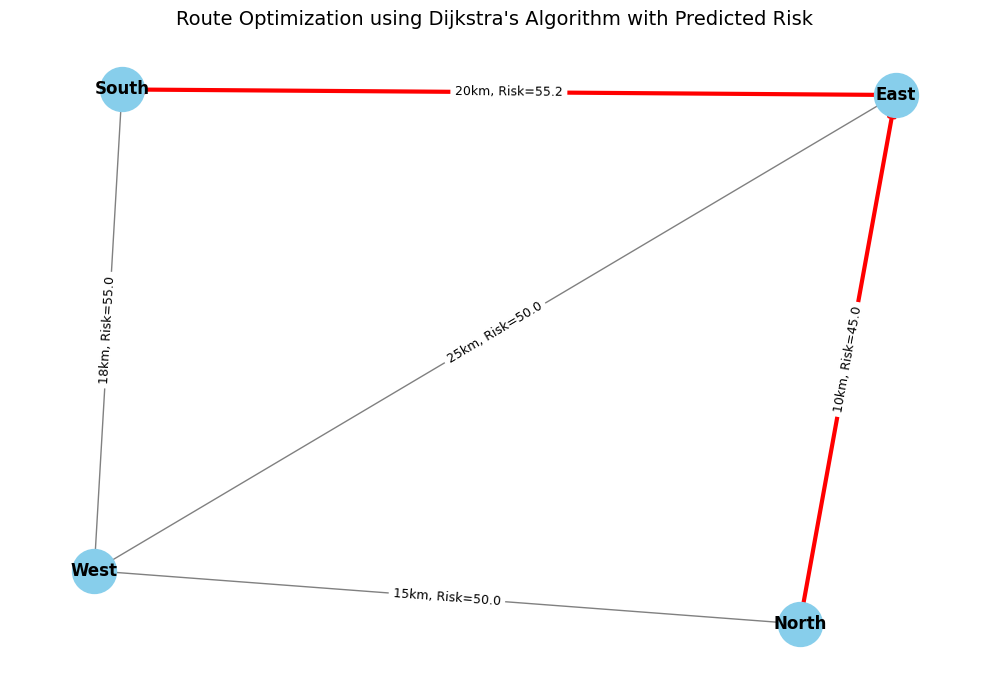

In [45]:
import networkx as nx
import matplotlib.pyplot as plt

# Define your edges
edges = [
    ('North', 'East', 10, 45.0000),
    ('North', 'West', 15, 49.9832),
    ('South', 'East', 20, 55.2170),
    ('East', 'South', 12, 39.9920),
    ('West', 'South', 18, 54.9926),
    ('West', 'East', 25, 49.9964)
]

# Create graph
G = nx.DiGraph()

# Add edges with composite weights (distance + 0.5 * risk)
for start, end, distance, risk in edges:
    weight = distance + 0.5 * risk
    G.add_edge(start, end, weight=weight, label=f"{distance}km, Risk={risk:.1f}")

# Compute shortest path from North to South
path = nx.dijkstra_path(G, source='North', target='South', weight='weight')
path_edges = list(zip(path, path[1:]))

# Draw graph
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 7))

# Nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=1000)

# All edges
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True)

# Highlight the optimal path
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

# Labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Edge labels
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

# Title and display
plt.title("Route Optimization using Dijkstra's Algorithm with Predicted Risk", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

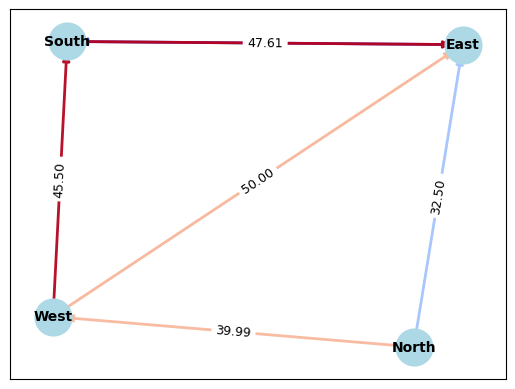

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Sample data
data = {
    'Start': ['North', 'North', 'South', 'East', 'West', 'West'],
    'End': ['East', 'West', 'East', 'South', 'South', 'East'],
    'Distance_km': [10, 15, 20, 12, 18, 25],
    'Predicted_Risk': [45.0000, 49.9832, 55.2170, 39.9920, 54.9926, 49.9964]
}

df = pd.DataFrame(data)

# Create graph
G = nx.DiGraph()

# Add edges with attributes
for i, row in df.iterrows():
    cost = row['Distance_km'] + row['Predicted_Risk'] * 0.5
    G.add_edge(row['Start'], row['End'], weight=cost, risk=row['Predicted_Risk'])

# Define layout
pos = nx.spring_layout(G, seed=42)

# Extract edge colors based on risk
edges = G.edges(data=True)
colors = [attr['risk'] for _, _, attr in edges]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')

# Draw edges with colormap
edges_drawn = nx.draw_networkx_edges(
    G, pos, edgelist=G.edges(),
    edge_color=colors, edge_cmap=plt.cm.coolwarm, width=2
)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Edge labels for weight
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=plt.Normalize(vmin=min(colors), vmax=max(colors)))
sm.set_array([])  # Add dummy array to allow colorbar
plt.colorbar(sm, label='Predicted Risk Level')

plt.title("Traffic Route Network with Risk Weights")
plt.axis('off')
plt.tight_layout()
plt.show()


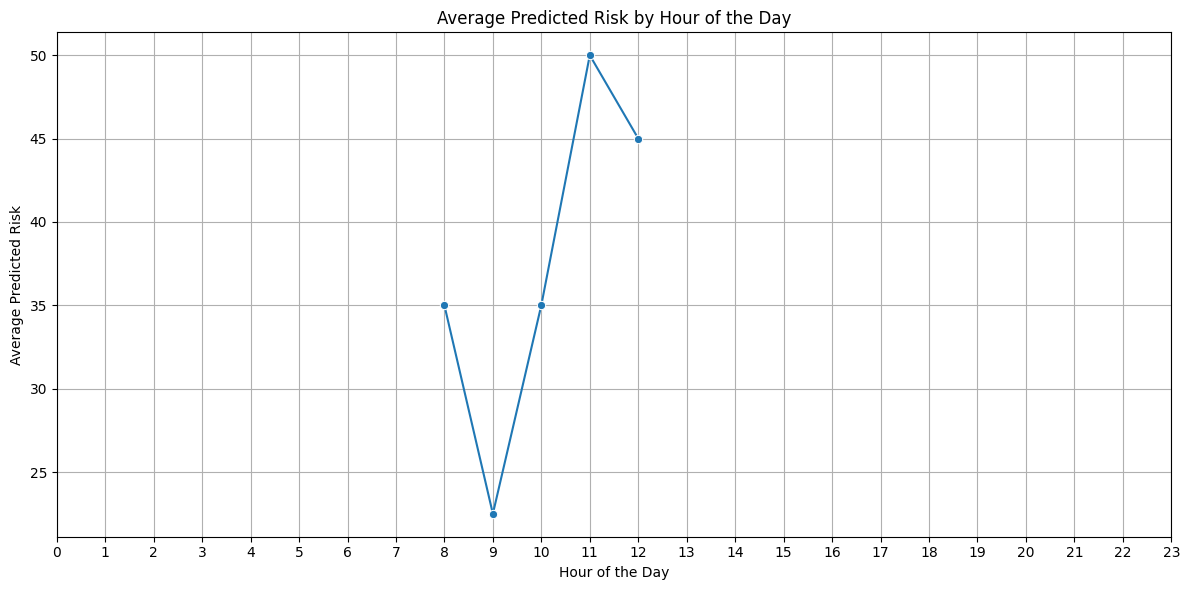

C:\Users\HP\AppData\Local\Temp\ipykernel_18872\1987024691.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_risk, x='DAY_NAME', y='Predicted_Risk', palette='viridis')


<function matplotlib.pyplot.show(close=None, block=None)>

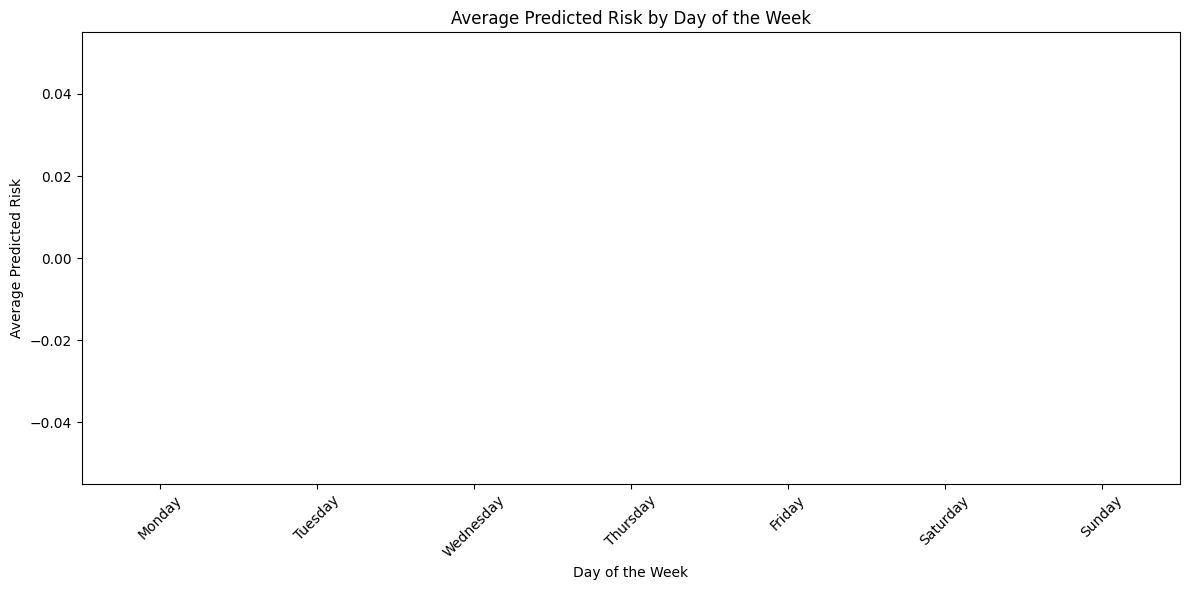

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Load the predicted dataset
df_routes = df_routes = pd.read_csv("predicted_route_risks.csv")

days = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
df_routes['DAY_NAME'] = df_routes['DAY_OF_WEEK'].map(days)

# Group by hour and compute average risk
hourly_risk = df_routes.groupby('HOUR')['Predicted_Risk'].mean().reset_index()

# Group by day and compute average risk
daily_risk = df_routes.groupby('DAY_NAME')['Predicted_Risk'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).reset_index()

# Plot 1: Hourly Risk 
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_risk, x='HOUR', y='Predicted_Risk', marker='o')
plt.title('Average Predicted Risk by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Predicted Risk')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Daily Risk
plt.figure(figsize=(12, 6))
sns.barplot(data=daily_risk, x='DAY_NAME', y='Predicted_Risk', palette='viridis')
plt.title('Average Predicted Risk by Day of the Week')  
plt.xlabel('Day of the Week')
plt.ylabel('Average Predicted Risk')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

In [21]:
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error , r2_score
import joblib

# Load the cleaned dataset 
file_path = "data/cleaned_traffic_congestion.csv"
chunk_size = 100_000

chunks = []
for c in pd.read_csv(file_path,chunksize=chunk_size):
    chunks.append(c)
    if len(chunks) == 5:
        break
df_cleaned = pd.concat(chunks , ignore_index=True)
print("Data Loaded:" ,  df_cleaned.shape)

# Define features and target
num_cols = ['SPEED' , 'BUS_COUNT' , 'NUM_READS' ,'HOUR'] 
cat_cols = ['REGION' , 'DAY_OF_WEEK' , 'MONTH']
target_col = 'SPEED'

X=df_cleaned[num_cols + cat_cols]
y = df_cleaned[target_col]

# Train_test split 
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size=0.2 ,random_state=42)

# Preprocessing 
numeric_transformer = StandardScaler()
categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)   

preprocessor = ColumnTransformer([
    ('num' , numeric_transformer , num_cols),
    ('cat' ,categorical_transformer , cat_cols)
])

model = RandomForestRegressor(
     n_estimators=50,
     max_depth=15,
     n_jobs=-1,
     random_state=42
 )
pipeline = Pipeline(steps=[
    ('preprocessor' , preprocessor),
    ('model' , model)
])

# Train Model
print("Training Started...")
pipeline.fit(X_train , y_train)
print("Training Completed !")

# Evaluate & Store Predictions

y_pred = pipeline.predict(X_test)
y_true = y_test.to_numpy()

# Save arrays for later analysis
import numpy as np 
np.save("y_true.npy" , y_true)
np.save("y_pred.npy" , y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_true , y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")
print("y_true and y_pred arrays saved as y_true.npy and y_pred.npy")

# save the model 
joblib.dump(pipeline , "optimized_traffic_model.pkl")
print("Model saved as optimized_traffic_model.pkl")


Data Loaded: (500000, 18)
Training Started...
Training Completed !
RMSE : 0.04
R2 Score: 1.00
y_true and y_pred arrays saved as y_true.npy and y_pred.npy
Model saved as optimized_traffic_model.pkl


RMSE : 0.04
R2 Score: 1.00
MAE: 0.0002


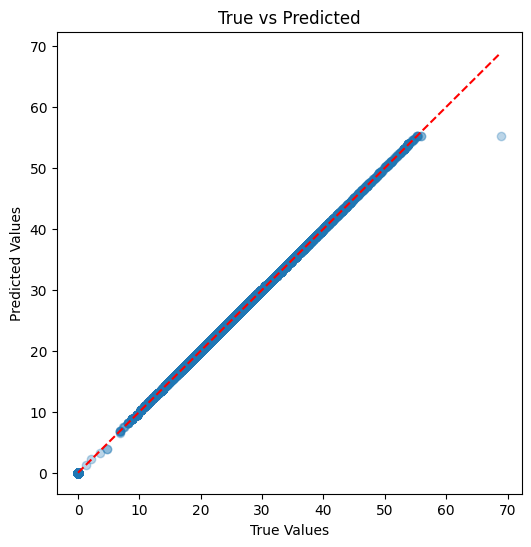

In [22]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Load the arrays
y_true = np.load("y_true.npy")
y_pred = np.load("y_pred.npy")

# Metrics 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_true , y_pred)
mae = mean_absolute_error(y_true , y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")
print(f"MAE: {mae:.4f}")

# Plot true vs predicted 
plt.figure(figsize=(6,6))
plt.scatter(y_true , y_pred , alpha=0.3)
plt.plot([y_true.min() , y_true.max() ] ,
         [y_true.min() , y_true.max() ] ,
         color = 'red' , linestyle = '--'
)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted")
plt.show()

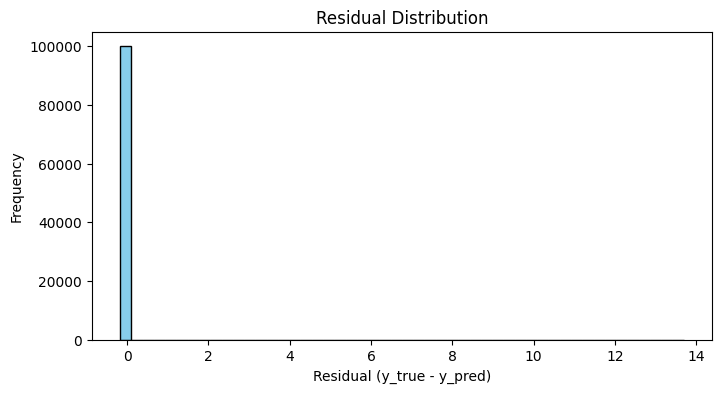

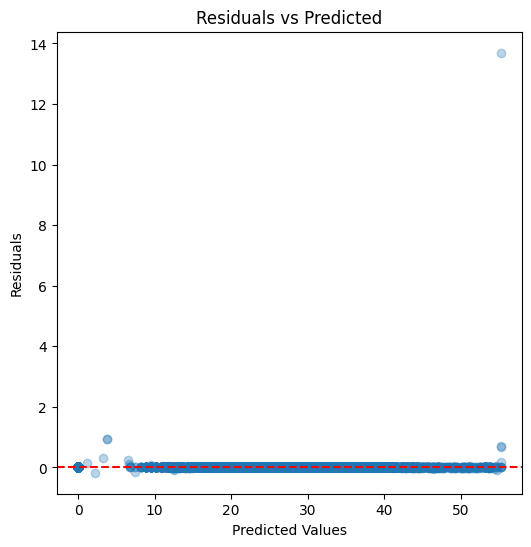

        SPEED  BUS_COUNT  NUM_READS  HOUR  ... MONTH  y_true   y_pred  residual
111276  68.90          6         80     4  ...     4   68.90  55.2070   13.6930
250302   4.77         60        743    21  ...     7    4.77   3.8174    0.9526
250948   4.77         53        673    21  ...     7    4.77   3.8174    0.9526
126949  55.91          7         51     1  ...     4   55.91  55.2072    0.7028
39482   55.91          6         62     3  ...     3   55.91  55.2216    0.6884
248402   3.55         56        773    20  ...     7    3.55   3.2462    0.3038
360540   6.82        250       4063     9  ...     6    6.82   6.5888    0.2312
7366    55.40          6         36     3  ...     3   55.40  55.2216    0.1784
258370   2.05         58        990    22  ...     7    2.05   2.2254   -0.1754
257559   1.36         61        970    22  ...     7    1.36   1.2004    0.1596

[10 rows x 10 columns]
Error analysis saved as error_analysis_day42.csv


In [24]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 

# Load the arrays 
y_true = np.load("y_true.npy")
y_pred = np.load("y_pred.npy")

# Compute Residuals 
residuals = y_true - y_pred

# Residuals Distributions 
plt.figure(figsize=(8,4))
plt.hist(residuals , bins = 50 , color = 'skyblue' ,edgecolor = 'black')
plt.title("Residual Distribution")
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Frequency")
plt.show()

# Residuals vs Predicted 
plt.figure(figsize=(6,6))
plt.scatter(y_pred , residuals ,alpha =0.3)
plt.axhline(y=0 , color = 'red' , linestyle = '--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals") 
plt.title("Residuals vs Predicted")
plt.show()

# Identify Error patterns 
df_errors = pd.DataFrame(X_test.copy())
df_errors['y_true'] = y_true
df_errors['y_pred'] = y_pred
df_errors['residual'] = residuals

# To find worst predictions
worst_cases = df_errors.iloc[np.argsort(np.abs (df_errors['residual']))[::-1]].head(10)
print(worst_cases)

df_errors.to_csv("error_analysis_42.csv",index = False)
print("Error analysis saved as error_analysis_day42.csv")

In [2]:
import pandas as pd 
import numpy as np 
import joblib
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error , r2_score

#Load the Data
df_cleaned = pd.read_csv("data/cleaned_traffic_congestion.csv" , nrows = 5000)

X = df_cleaned.drop("SPEED" , axis =1)
y = df_cleaned["SPEED"]

# Train test split 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

# Feature Engineering 

def rush_hour_flag(hour):
    return 1 if(7 <= hour <=9) or (16 <=hour <=18) else 0

if "hour" in X_train.columns:
    X_train["rush_hour"] = X_train["hour"].apply(rush_hour_flag)
    X_test["rush_hour"] = X_test["hour"].apply(rush_hour_flag)
    
# Preprocessing Setup

numeric_features = X.select_dtypes(include=["int64" , "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numerical_transformer = Pipeline(steps=[
    ("scaler" ,StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("onehot" , OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers= [
        ("num" , numerical_transformer , numeric_features),
        ("cat" , categorical_transformer , categorical_features)
    ]
)
rf = RandomForestRegressor(random_state=42)
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model" , rf)
])

param_grid = {
    "model__n_estimators":[50 , 100],
    "model__max_depth":[10,15,20],
    "model__min_samples_split":[2,5]
}
grid_search = GridSearchCV(
    pipeline , param_grid , cv=3,
    n_jobs=-1 , scoring="neg_root_mean_squared_error"
)
print("Training Started")
grid_search.fit(X_train , y_train)
print("Training Completed")

print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate improved model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")
print(f"MAE: {mae:.4f}")

# Save updated predictions
np.save("y_true_day43.npy" , y_test)
np.save("y_pred_day43.npy" , y_pred)

# Saved improved model 
joblib.dump(best_model , "optimized_traffic_model_day43.pkl")
print("Improved model saved as optimized_traffic_model_day43.pkl")





Training Started
Training Completed
Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}
RMSE : 1.62
R2 Score: 0.91
MAE: 1.0054
Improved model saved as optimized_traffic_model_day43.pkl


In [5]:
%pip install fastapi uvicorn pandas scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# day45_streamlit_app.py
import streamlit as st
import pandas as pd
import joblib

# ----------------------
# 1. Load trained model
# ----------------------
model = joblib.load("optimized_traffic_model_day43.pkl")

# ----------------------
# 2. App Title
# ----------------------
st.set_page_config(page_title="Traffic Speed Prediction", layout="centered")
st.title("🚦 Traffic Speed Prediction")
st.write("Enter the traffic details below to predict speed.")

# ----------------------
# 3. User Inputs
# ----------------------
SPEED = st.number_input("Current Speed (km/h)", min_value=0.0, max_value=200.0, value=40.0)
BUS_COUNT = st.number_input("Bus Count", min_value=0, max_value=500, value=10)
NUM_READS = st.number_input("Number of Reads", min_value=0, max_value=10000, value=500)
HOUR = st.slider("Hour of Day", 0, 23, 8)
REGION = st.selectbox("Region", ["North", "South", "East", "West"])
DAY_OF_WEEK = st.selectbox("Day of Week", ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
MONTH = st.selectbox("Month", ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
                                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
rush_hour = 1 if HOUR in [7, 8, 9, 17, 18, 19] else 0

# ----------------------
# 4. Prediction Button
# ----------------------
if st.button("Predict Speed"):
    input_df = pd.DataFrame([{
        "SPEED": SPEED,
        "BUS_COUNT": BUS_COUNT,
        "NUM_READS": NUM_READS,
        "HOUR": HOUR,
        "REGION": REGION,
        "DAY_OF_WEEK": DAY_OF_WEEK,
        "MONTH": MONTH,
        "rush_hour": rush_hour
    }])

    prediction = model.predict(input_df)[0]
    st.success(f"Predicted Speed: {prediction:.2f} km/h")


2025-08-12 12:59:18.601 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-12 12:59:18.602 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-12 12:59:19.147 
  command:

    streamlit run C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-08-12 12:59:19.148 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-12 12:59:19.149 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-12 12:59:19.150 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-12 12:5